## Machine Learning II Group Assignment - Section 1 Group 5
*Jia Yi Rachel Lee, Thomas Christian Matenco, Maria-Irina Popa, Roberto Cummings, Enzo Jerez*

# **<span style="color:#1DB954">PREDICTING THE NEXT **<u>HIT SONG** BASED ON AUDIO FEATURES AND GENRES</span>**

**Objective:** To develop a classification model to predict hit songs\
**Business Problem:** "Can we predict whether a song will be a hit based on its audio characteristics? We help record labels identify commercial potential before investing in promotion"\
**Data:** Spotify Tracks Dataset (https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

This notebook consists of the following sections:
1. Data Audit, Data Cleaning and Data Manipulation
2. Features Engineering
3. Exploratory Data Analysis (EDA)
4. Preprocessing for Machine Learning Modelling
5. Classification Model - Option 1: Classification Tree
6. Classification Model - Option 2: Random Forest
7. Classification Model - Option 3: Boosting
8. Comparing the Classification Models and Final Selection
9. Business Insights
10. Connecting All the Dots: Recommendations and Conclusion
11. Hands-on Activity

<span style="color: red;">****Note to Professor:** A hands-on activity is included at the end of this notebook (Section 11) and requires user input. If you encounter any issues when restarting the kernel or running other cells, please ensure that the final cell is not awaiting input - type '`quit`' to exit the activity.</span>*

## **1. Data Audit, Data Cleaning and Data Manipulation**

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

In [2]:
!{sys.executable} -m pip install plotly
!{sys.executable} -m pip install nbformat ipython
!{sys.executable} -m pip install squarify

In [3]:
import numpy as np
import pandas as pd

import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import squarify
import math

spotify_green_colour = '#1DB954'

sns.set_style('whitegrid')
sns.set_palette([spotify_green_colour])
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[spotify_green_colour])
plt.rcParams['font.family'] = 'DejaVu Sans'

pd.options.display.float_format = '{:.3f}'.format
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

from matplotlib.ticker import FuncFormatter
from IPython.display import display

In [4]:
# Scikit-learn
from sklearn import metrics
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# XGBoost
from xgboost import XGBClassifier

### **1.1 Data Loading**

In [5]:
# Load data
filename = 'Spotify_dataset.csv'
df = pd.read_csv(filename)
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.032,0.000,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.076,0.924,0.000,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.056,0.210,0.000,0.117,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.060,0,-18.515,1,0.036,0.905,0.000,0.132,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.053,0.469,0.000,0.083,0.167,119.949,4,acoustic


In [6]:
print('Records and variables: ', df.shape)
print('Column names: ', df.columns.to_list())

Records and variables:  (114000, 21)
Column names:  ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [8]:
# Check number of unique values
df.nunique().sort_values()

mode                     2
explicit                 2
time_signature           5
key                     12
popularity             101
track_genre            114
danceability          1174
speechiness           1489
liveness              1722
valence               1790
energy                2083
acousticness          5061
instrumentalness      5346
loudness             19480
artists              31437
tempo                45653
album_name           46589
duration_ms          50697
track_name           73608
track_id             89741
Unnamed: 0          114000
dtype: int64

In [9]:
# Check summary statistics for numerical columns
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000
mean,56999.500,33.239,228029.153,0.567,0.641,5.309,-8.259,0.638,0.085,0.315,0.156,0.214,0.474,122.148,3.904
std,32909.110,22.305,107297.713,0.174,0.252,3.560,5.029,0.481,0.106,0.333,0.310,0.190,0.259,29.978,0.433
min,0.000,0.000,0.000,0.000,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,28499.750,17.000,174066.000,0.456,0.472,2.000,-10.013,0.000,0.036,0.017,0.000,0.098,0.260,99.219,4.000
50%,56999.500,35.000,212906.000,0.580,0.685,5.000,-7.004,1.000,0.049,0.169,0.000,0.132,0.464,122.017,4.000
75%,85499.250,50.000,261506.000,0.695,0.854,8.000,-5.003,1.000,0.085,0.598,0.049,0.273,0.683,140.071,4.000
max,113999.000,100.000,5237295.000,0.985,1.000,11.000,4.532,1.000,0.965,0.996,1.000,1.000,0.995,243.372,5.000


In [10]:
# Check unique values for categorical columns
for col_name in df.select_dtypes(include='object').columns:
    print(f"\n---{col_name}---")
    print(df[col_name].unique())


---track_id---
['5SuOikwiRyPMVoIQDJUgSV' '4qPNDBW1i3p13qLCt0Ki3A'
 '1iJBSr7s7jYXzM8EGcbK5b' ... '6x8ZfSoqDjuNa5SVP5QjvX'
 '2e6sXL2bYv4bSz6VTdnfLs' '2hETkH7cOfqmz3LqZDHZf5']

---artists---
['Gen Hoshino' 'Ben Woodward' 'Ingrid Michaelson;ZAYN' ...
 'Cuencos Tibetanos Sonidos Relajantes'
 'Bryan & Katie Torwalt;Brock Human' 'Jesus Culture']

---album_name---
['Comedy' 'Ghost (Acoustic)' 'To Begin Again' ...
 '#20 Sueños Vividos - Música Intrumental Suave 2018 para Dormir Bien y Relajarse Profundamente'
 'Frecuencias Álmicas en 432hz (Solo Piano)' 'Revelation Songs']

---track_name---
['Comedy' 'Ghost - Acoustic' 'To Begin Again' ... 'Water Into Light'
 'Miss Perfumado' 'Barbincor']

---track_genre---
['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient' 'anime'
 'black-metal' 'bluegrass' 'blues' 'brazil' 'breakbeat' 'british'
 'cantopop' 'chicago-house' 'children' 'chill' 'classical' 'club' 'comedy'
 'country' 'dance' 'dancehall' 'death-metal' 'deep-house' 'detroit-techno'
 'disco' 

### **1.2 Data Cleaning**

In [11]:
# Create new df to store cleaned data
df_clean = df.copy()

In [12]:
# Remove index column
df_clean.drop(columns=['Unnamed: 0'], inplace=True)

In [13]:
# Check for duplicates
print('Total rows:', len(df_clean))

duplicate_rows = df_clean.duplicated().sum()
print('Number of duplicate rows:', duplicate_rows)

Total rows: 114000
Number of duplicate rows: 450


In [14]:
# Remove duplicate rows
df_clean = df_clean.drop_duplicates()
print('Rows after removing duplicates:', len(df_clean))

Rows after removing duplicates: 113550


In [15]:
# Check for duplicate tracks
dup_counts = df_clean.groupby(['track_name', 'artists']).size()
dup_pairs  = dup_counts[dup_counts > 1]

print(f'Total unique (track, artist) pairs appearing more than once: {len(dup_pairs)}')
print(f'Total extra duplicate rows: {(dup_pairs - 1).sum()}')
print(f'\nTop 20 most duplicated (track, artist) pairs:')
print(dup_pairs.sort_values(ascending=False).head(20).to_frame('count'))

Total unique (track, artist) pairs appearing more than once: 16220
Total extra duplicate rows: 32206

Top 20 most duplicated (track, artist) pairs:
                                                                   count
track_name                        artists                               
Run Rudolph Run                   Chuck Berry                        151
Little Saint Nick - 1991 Remix    The Beach Boys                      74
Last Last                         Burna Boy                           70
Frosty The Snowman                Ella Fitzgerald                     68
Christmas Time                    Bryan Adams                         66
CÓMO SE SIENTE - Remix            Jhayco;Bad Bunny                    64
Sleigh Ride                       Ella Fitzgerald                     60
RUMBATÓN                          Daddy Yankee                        57
X ÚLTIMA VEZ                      Daddy Yankee;Bad Bunny              57
Feliz Cumpleaños Ferxxo           Feid           

In [16]:
# View duplicate tracks
# Get top 5 most duplicated (track_name, artists) pairs
top5_pairs = dup_pairs.sort_values(ascending=False).head(5).index.tolist()

# Filter df_clean to show those rows
mask = pd.MultiIndex.from_frame(
    df_clean[['track_name', 'artists']]
).isin(top5_pairs)

df_dups_view = df_clean[mask]\
    [['track_name', 'artists', 'track_genre', 'popularity',
      'danceability', 'energy']]\
    .sort_values(['track_name', 'artists'])

print('Sample of duplicated (track, artist) entries:')
df_dups_view.head(10)

Sample of duplicated (track, artist) entries:


,track_name,artists,track_genre,popularity,danceability,energy
91317,Christmas Time,Bryan Adams,rock,0,0.503,0.582
91328,Christmas Time,Bryan Adams,rock,0,0.503,0.582
91330,Christmas Time,Bryan Adams,rock,0,0.503,0.582
91331,Christmas Time,Bryan Adams,rock,0,0.503,0.582
91332,Christmas Time,Bryan Adams,rock,0,0.503,0.582
91333,Christmas Time,Bryan Adams,rock,0,0.503,0.582
91335,Christmas Time,Bryan Adams,rock,0,0.503,0.582
91338,Christmas Time,Bryan Adams,rock,0,0.503,0.582
91341,Christmas Time,Bryan Adams,rock,0,0.503,0.582
91342,Christmas Time,Bryan Adams,rock,0,0.503,0.582


In [17]:
# Same song appears across multiple genres — keep highest popularity entry
rows_before = len(df_clean)

df_clean = df_clean\
    .sort_values('popularity', ascending=False)\
    .drop_duplicates(subset=['track_name', 'artists'], keep='first')\
    .reset_index(drop=True)

rows_after = len(df_clean)

print(f'Rows before deduplication: {rows_before:,}')
print(f'Rows removed:              {rows_before - rows_after:,}')
print(f'Rows after deduplication:  {rows_after:,}')

Rows before deduplication: 113,550
Rows removed:              32,206
Rows after deduplication:  81,344


In [18]:
# Check for missing values
df_clean.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [19]:
df_clean[df_clean.isnull().any(axis=1)]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
78464,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.460,0,0.060,0.690,0.004,0.075,0.734,138.391,4,k-pop


Since there is only 1 row with missing values, removing this data will not cause significant data loss and will therefore be removed.

In [20]:
# Drop rows with missing values and check afterwards
df_clean = df_clean.dropna()
df_clean.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [21]:
# Fix datatypes
df_clean["mode"] = df_clean["mode"].astype(bool)
df_clean["track_genre"] = df_clean["track_genre"].astype("category")
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 81343 entries, 0 to 81343
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   track_id          81343 non-null  object  
 1   artists           81343 non-null  object  
 2   album_name        81343 non-null  object  
 3   track_name        81343 non-null  object  
 4   popularity        81343 non-null  int64   
 5   duration_ms       81343 non-null  int64   
 6   explicit          81343 non-null  bool    
 7   danceability      81343 non-null  float64 
 8   energy            81343 non-null  float64 
 9   key               81343 non-null  int64   
 10  loudness          81343 non-null  float64 
 11  mode              81343 non-null  bool    
 12  speechiness       81343 non-null  float64 
 13  acousticness      81343 non-null  float64 
 14  instrumentalness  81343 non-null  float64 
 15  liveness          81343 non-null  float64 
 16  valence           81343 non

In [22]:
# Check summary statistics after cleaning
print(f"Total number of rows after data cleaning: {len(df_clean)}")
df_clean.describe()

Total number of rows after data cleaning: 81343


,popularity,duration_ms,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000
mean,35.249,231394.471,0.559,0.635,5.286,-8.599,0.089,0.330,0.185,0.220,0.463,122.135,3.897
std,19.410,116474.438,0.178,0.259,3.557,5.306,0.117,0.340,0.332,0.198,0.263,30.122,0.457
min,0.000,8586.000,0.000,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,21.000,173862.000,0.446,0.455,2.000,-10.458,0.036,0.016,0.000,0.099,0.241,99.383,4.000
50%,35.000,215200.000,0.573,0.678,5.000,-7.267,0.049,0.190,0.000,0.133,0.449,122.028,4.000
75%,49.000,267338.000,0.690,0.857,8.000,-5.143,0.087,0.629,0.153,0.283,0.676,140.124,4.000
max,100.000,5237295.000,0.985,1.000,11.000,4.532,0.965,0.996,1.000,1.000,0.995,243.372,5.000


## **2. Features Engineering**

To enable more insightful analyses, the following variables are created.

In [23]:
# Duration in minutes
df_clean['duration_min'] = df_clean['duration_ms']/ 60000

In [24]:
# Number of artsts in collaboration
df_clean['num_artists'] = df_clean['artists'].apply(lambda x: len(str(x).split(';')))

In [25]:
# To indicate collaboration
df_clean['is_collab'] = df_clean['artists'].str.contains(';', regex=False).astype(bool)

In [26]:
# Combining energy and danceability
df_clean['energy_danceability'] = df_clean['energy'] * df_clean['danceability']

In [27]:
# Create mood intensity
df_clean['mood_intensity'] = df_clean['valence'] * df_clean['energy']

In [28]:
# Check data types afterwards
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 81343 entries, 0 to 81343
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   track_id             81343 non-null  object  
 1   artists              81343 non-null  object  
 2   album_name           81343 non-null  object  
 3   track_name           81343 non-null  object  
 4   popularity           81343 non-null  int64   
 5   duration_ms          81343 non-null  int64   
 6   explicit             81343 non-null  bool    
 7   danceability         81343 non-null  float64 
 8   energy               81343 non-null  float64 
 9   key                  81343 non-null  int64   
 10  loudness             81343 non-null  float64 
 11  mode                 81343 non-null  bool    
 12  speechiness          81343 non-null  float64 
 13  acousticness         81343 non-null  float64 
 14  instrumentalness     81343 non-null  float64 
 15  liveness             813

In [29]:
# Split numerical vs non-numerical columns
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_clean.select_dtypes(include='category').columns
bool_cols = df_clean.select_dtypes(include='bool').columns
str_cols = df_clean.select_dtypes(include='object').columns

print(num_cols)
print(cat_cols)
print(bool_cols)
print(str_cols)

Index(['popularity', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'duration_min',
       'num_artists', 'energy_danceability', 'mood_intensity'],
      dtype='object')
Index(['track_genre'], dtype='object')
Index(['explicit', 'mode', 'is_collab'], dtype='object')
Index(['track_id', 'artists', 'album_name', 'track_name'], dtype='object')


In [30]:
# Checking missing values
df_clean.isna().sum()

track_id               0
artists                0
album_name             0
track_name             0
popularity             0
duration_ms            0
explicit               0
danceability           0
energy                 0
key                    0
loudness               0
mode                   0
speechiness            0
acousticness           0
instrumentalness       0
liveness               0
valence                0
tempo                  0
time_signature         0
track_genre            0
duration_min           0
num_artists            0
is_collab              0
energy_danceability    0
mood_intensity         0
dtype: int64

## **3. Exploratory Data Analysis (EDA)**

### ***3.1 Exploring the overall data***

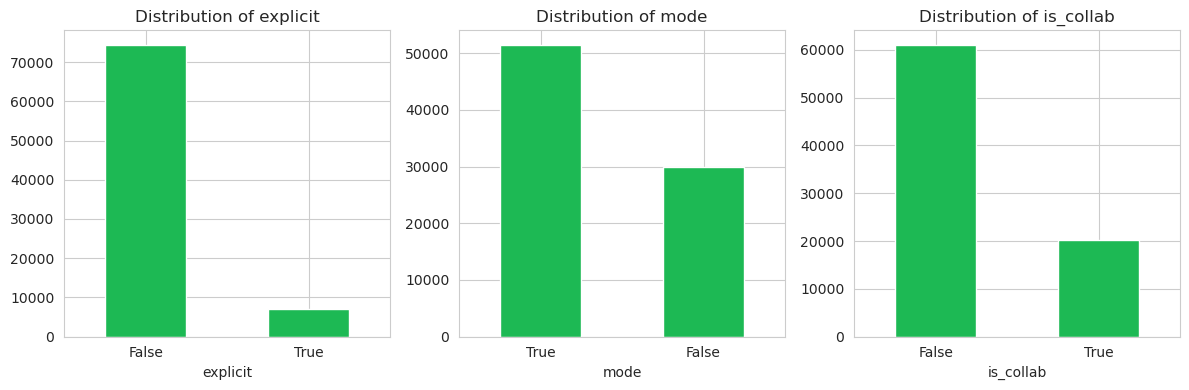

In [31]:
# Plot bar charts of Boolean variables
fig, axes = plt.subplots(1, len(bool_cols), figsize=(12, 4))

for i, col in enumerate(bool_cols):
    df_clean[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [32]:
# Cardinality checks for categorical variables
for col in cat_cols:
    print(f"{col}: {df_clean[col].nunique()} unique values")

track_genre: 114 unique values


In [33]:
df_clean['track_genre'].value_counts().describe()

count   114.000
mean    713.535
std     216.378
min     201.000
25%     560.750
50%     774.000
75%     895.000
max     996.000
Name: count, dtype: float64

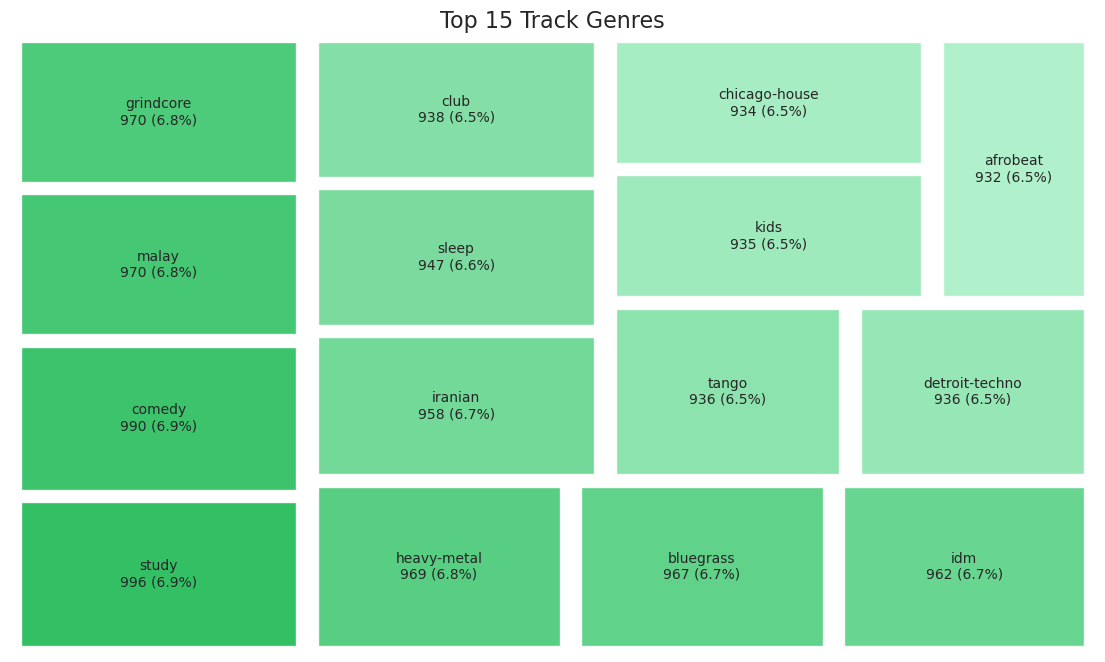

In [34]:
# Plot treemap for track_genre - Top 15
top_n = 15
genre_counts = df_clean['track_genre'].value_counts().head(top_n)

spotify_green = '#1DB954'
cmap = mcolors.LinearSegmentedColormap.from_list(
    'spotify_green_gradient',
    [spotify_green, '#A8F0C6']
)

colors = [cmap(i) for i in np.linspace(0, 1, len(genre_counts))]

total = genre_counts.sum()

labels = [
    f"{genre}\n{count} ({count/total:.1%})"
    for genre, count in zip(genre_counts.index, genre_counts.values)
]

plt.figure(figsize=(14, 8))
squarify.plot(
    sizes=genre_counts.values,
    label=labels,
    color=colors,
    alpha=0.9,
    pad=True
)

plt.title(f"Top {top_n} Track Genres", fontsize=16)
plt.axis("off")
plt.show()

In [35]:
genres_list = sorted(df_clean['track_genre'].unique())
print(', '.join(genres_list))

acoustic, afrobeat, alt-rock, alternative, ambient, anime, black-metal, bluegrass, blues, brazil, breakbeat, british, cantopop, chicago-house, children, chill, classical, club, comedy, country, dance, dancehall, death-metal, deep-house, detroit-techno, disco, disney, drum-and-bass, dub, dubstep, edm, electro, electronic, emo, folk, forro, french, funk, garage, german, gospel, goth, grindcore, groove, grunge, guitar, happy, hard-rock, hardcore, hardstyle, heavy-metal, hip-hop, honky-tonk, house, idm, indian, indie, indie-pop, industrial, iranian, j-dance, j-idol, j-pop, j-rock, jazz, k-pop, kids, latin, latino, malay, mandopop, metal, metalcore, minimal-techno, mpb, new-age, opera, pagode, party, piano, pop, pop-film, power-pop, progressive-house, psych-rock, punk, punk-rock, r-n-b, reggae, reggaeton, rock, rock-n-roll, rockabilly, romance, sad, salsa, samba, sertanejo, show-tunes, singer-songwriter, ska, sleep, songwriter, soul, spanish, study, swedish, synth-pop, tango, techno, trance

In [36]:
# Establish genre mapping
genre_map = {'classical': ['classical', 'opera', 'piano'],
             'folk_country':['folk', 'country', 'bluegrass', 'acoustic', 'honky-tonk', 'singer-songwriter', 'songwriter', 'guitar'],
             'indie_alt': ['indie', 'alternative'],
             'jazz_blues_funk':['jazz', 'blues', 'funk', 'groove'],
             'hiphop_rnb':['hip-hop', 'r-n-b', 'soul', 'gospel'],
             'dance':['dance', 'disco', 'club', 'j-dance', 'party'],
             'electronic': ['edm', 'house', 'techno', 'trance', 'dubstep', 'electronic', 'electro', 'idm', 'hardstyle', 'garage', 'trip-hop',
                            'drum-and-bass', 'industrial', 'breakbeat', 'chicago-house', 'deep-house', 'detroit-techno', 'minimal-techno',
                            'progressive-house'],
             'rock':['rock', 'punk', 'grunge', 'emo', 'goth', 'hard-rock', 'punk-rock', 'rock-n-roll', 'rockabilly', 'psych-rock',
                     'alt-rock', 'j-rock'],
             'metal': ['metal', 'hardcore', 'grindcore', 'black-metal', 'death-metal',
                       'heavy-metal', 'metalcore'],
             'latin': ['latin', 'latino', 'salsa', 'samba', 'reggaeton', 'brazil', 'tango', 'forro', 'pagode', 'sertanejo', 'mpb'],
             'reggae_afro':['reggae', 'dub', 'afrobeat', 'dancehall', 'ska'],
             'kids': ['kids', 'children', 'disney', 'anime', 'j-idol'],
             'relax': ['chill', 'new-age', 'ambient', 'sleep', 'study'],
             'pop':['pop', 'french', 'german', 'spanish', 'turkish', 'indian', 'malay', 'swedish', 'iranian', 'british', 'j-pop', 'k-pop',
                    'cantopop', 'mandopop', 'indie-pop', 'pop-film', 'power-pop', 'synth-pop'],
             'other':['comedy', 'happy', 'romance', 'sad', 'show-tunes', 'breakbeat']}

In [37]:
# Create function to group the track genres
def group_genre(g):
    g = g.lower()
    
    if 'pop' in g:
        return 'pop'

    for group, keywords in genre_map.items():
        if any(k in g for k in keywords):
            return group

    return 'other'

In [38]:
# Apply group_genre
df_clean['genre_group'] = df_clean['track_genre'].apply(group_genre)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 81343 entries, 0 to 81343
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   track_id             81343 non-null  object  
 1   artists              81343 non-null  object  
 2   album_name           81343 non-null  object  
 3   track_name           81343 non-null  object  
 4   popularity           81343 non-null  int64   
 5   duration_ms          81343 non-null  int64   
 6   explicit             81343 non-null  bool    
 7   danceability         81343 non-null  float64 
 8   energy               81343 non-null  float64 
 9   key                  81343 non-null  int64   
 10  loudness             81343 non-null  float64 
 11  mode                 81343 non-null  bool    
 12  speechiness          81343 non-null  float64 
 13  acousticness         81343 non-null  float64 
 14  instrumentalness     81343 non-null  float64 
 15  liveness             813

In [39]:
grouped_genres = df_clean.groupby('genre_group')['track_genre'].unique()

for group, genres in grouped_genres.items():
    print(f"\n{group.upper()}:")
    print(', '.join(sorted(genres)))


CLASSICAL:
classical, opera, piano

DANCE:
club, dance, dancehall, disco, j-dance, party

ELECTRONIC:
breakbeat, chicago-house, deep-house, detroit-techno, drum-and-bass, dubstep, edm, electro, electronic, garage, hardstyle, house, idm, industrial, minimal-techno, progressive-house, techno, trance, trip-hop

FOLK_COUNTRY:
acoustic, bluegrass, country, folk, guitar, honky-tonk, singer-songwriter, songwriter

HIPHOP_RNB:
gospel, hip-hop, r-n-b, soul

INDIE_ALT:
alternative, indie

JAZZ_BLUES_FUNK:
blues, funk, groove, jazz

KIDS:
anime, children, disney, j-idol, kids

LATIN:
brazil, forro, latin, latino, mpb, pagode, reggaeton, salsa, samba, sertanejo, tango

METAL:
black-metal, death-metal, grindcore, hardcore, heavy-metal, metal, metalcore

OTHER:
comedy, happy, romance, sad, show-tunes, world-music

POP:
british, cantopop, french, german, indian, indie-pop, iranian, j-pop, k-pop, malay, mandopop, pop, pop-film, power-pop, spanish, swedish, synth-pop, turkish

REGGAE_AFRO:
afrobeat, d

In [40]:
# Fix genre_group datatype
df_clean['genre_group'] = df_clean['genre_group'].astype('category')
print(df_clean['genre_group'].dtypes)

category


In [41]:
# Check summary statistics of df_clean again
df_clean.describe()

,popularity,duration_ms,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min,num_artists,energy_danceability,mood_intensity
count,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000,81343.000
mean,35.249,231394.471,0.559,0.635,5.286,-8.599,0.089,0.330,0.185,0.220,0.463,122.135,3.897,3.857,1.375,0.361,0.311
std,19.410,116474.438,0.178,0.259,3.557,5.306,0.117,0.340,0.332,0.198,0.263,30.122,0.457,1.941,0.884,0.180,0.225
min,0.000,8586.000,0.000,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.143,1.000,0.000,0.000
25%,21.000,173862.000,0.446,0.455,2.000,-10.458,0.036,0.016,0.000,0.099,0.241,99.383,4.000,2.898,1.000,0.228,0.118
50%,35.000,215200.000,0.573,0.678,5.000,-7.267,0.049,0.190,0.000,0.133,0.449,122.028,4.000,3.587,1.000,0.373,0.275
75%,49.000,267338.000,0.690,0.857,8.000,-5.143,0.087,0.629,0.153,0.283,0.676,140.124,4.000,4.456,1.000,0.495,0.474
max,100.000,5237295.000,0.985,1.000,11.000,4.532,0.965,0.996,1.000,1.000,0.995,243.372,5.000,87.288,38.000,0.956,0.972


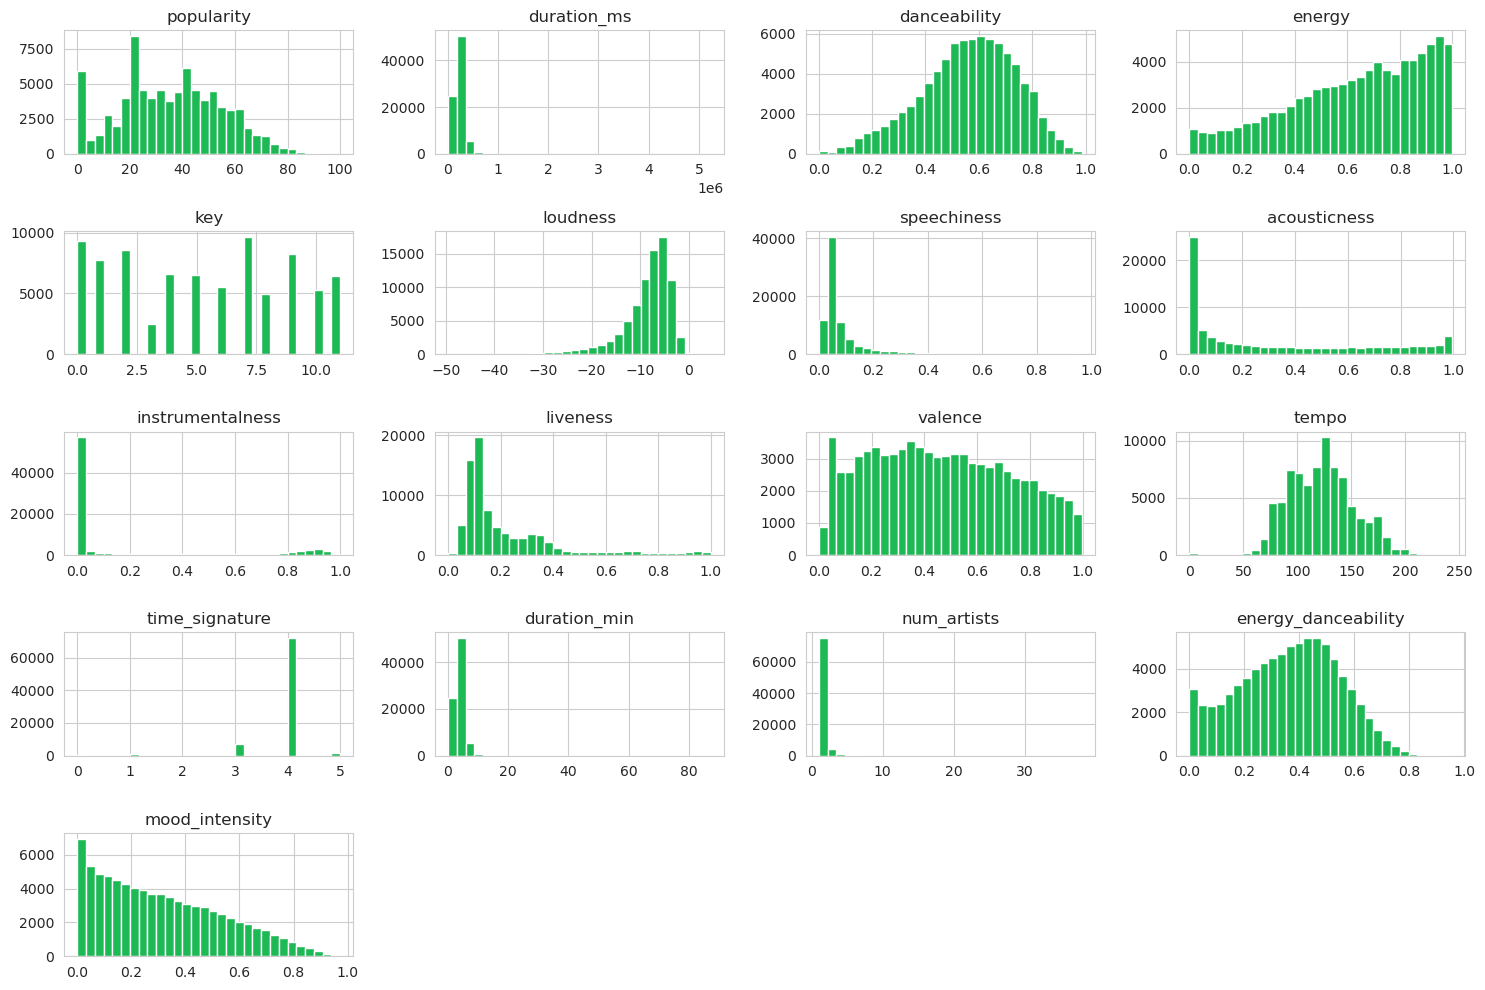

In [42]:
# Check distribution of numerical variables
df_clean[num_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

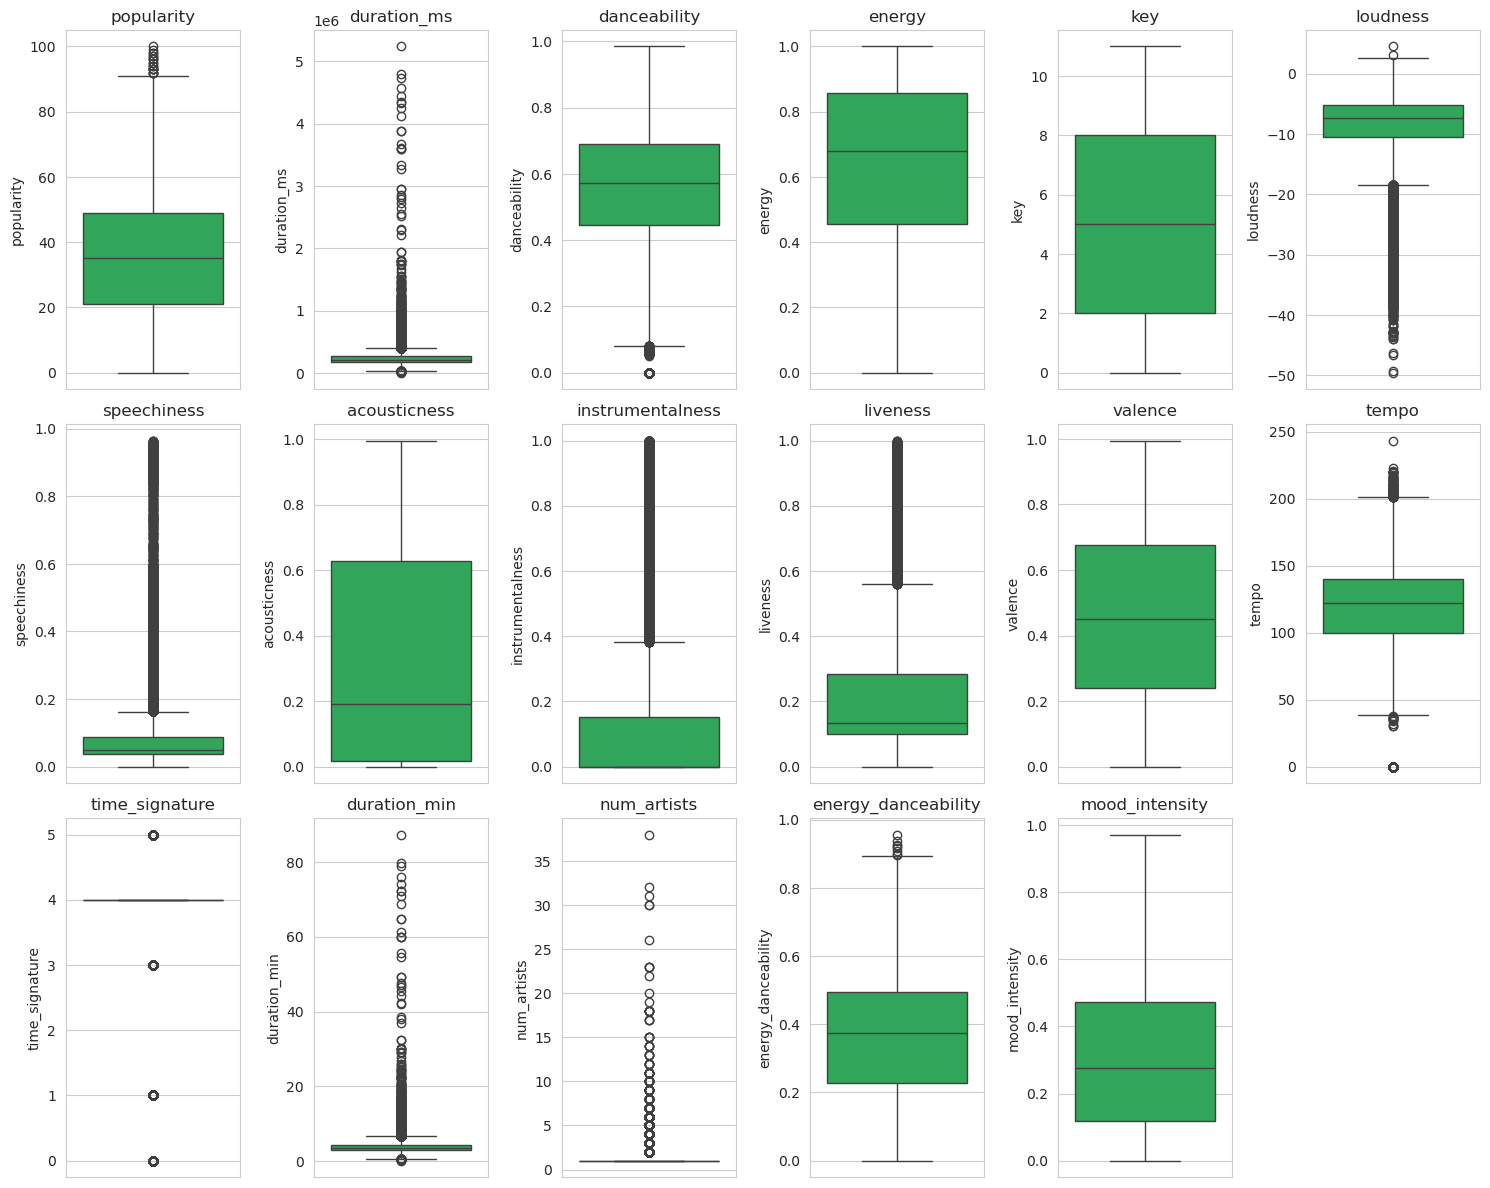

In [43]:
# Check for outliers in numerical variable
n_cols = 6
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df_clean[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### ***3.2 Removing outliers***

`duration_ms`: Most songs are between 2 and 5 min. To remove extreme outliers, songs with duration 10 min and above are removed.

In [44]:
# Remove outliers for duration_ms
df_clean = df_clean[df_clean['duration_ms'] < 600000]

`tempo`: Tempos below 40 and above 200 are rare musical compositions or tempo detection artifacts, and are unrealistic. 

In [45]:
df_clean = df_clean[(df_clean['tempo'] >= 40) & (df_clean['tempo'] <= 200)]

`loudness`: Values below -40dB are suspicious because that usually indicate that the audio is empty or represents low-level background noise. Values below -40dB will be removed.  

In [46]:
df_clean = df_clean[df_clean['loudness'] > -40]

### ***3.3 Create Target variable***

After cleaning the data, we can now create our target variable (`hit`).

The dataset provides a popularity score (0–100) calculated by Spotify's algorithm based on total streaming volume weighted by recency — entirely independent of audio features. A high popularity score reflects how often and how recently a track has been played, not its audio characteristics.

To translate this into a binary classification target, we define a **"hit"** as any track with a popularity score at or above the **75th percentile** (popularity ≥ X). This represents the top quartile of commercially successful tracks and provides a data-driven, objective boundary between mainstream success and the broader catalogue. Songs below this threshold are classified as non-hits — not because they lack quality, but because they have not achieved the level of streaming traction associated with commercial success.

It is important to note that popularity and "hit" are not equivalent. A song can be widely known yet score low due to recency weighting — older hits naturally decay over time as Spotify prioritises recent plays. Conversely, a song may briefly spike in popularity without sustained commercial success.

In [47]:
# Define threshold of a hit song
hit_threshold = df_clean['popularity'].quantile(0.75)

# Create target variable
df_clean['hit'] = (df_clean['popularity'] >= hit_threshold).astype(int)

### ***3.4 Target analysis***

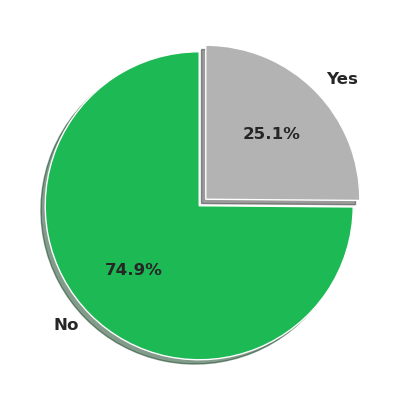

In [48]:
# Check split of target variables
target = 'hit'

unique, counts = np.unique(df_clean[target], return_counts=True)
percentages = counts / counts.sum() * 100
labels_custom = ['No', 'Yes']

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(counts, 
                                  labels=labels_custom, 
                                  autopct='%1.1f%%', 
                                  startangle=90,  # Clean rotation
                                  colors=[spotify_green_colour, '#B3B3B3'],  
                                  explode=(0.03, 0.03),  # Slight separation
                                  shadow=True,  # Depth
                                  textprops={'fontsize': 12, 'fontweight': 'bold'})

The target variable shows moderate class imbalance, with approximately 25% of observations classified as hits and 75% as non-hits. Since this level of imbalance is not severe and can be handled by standard classification models.

### ***3.5 Target vs variables analysis***

The analysis below compares the target variable (`hit`) with each numerical feature to examine how their distributions differ between hit and non-hit songs. This provides an intiial foundation for identifying which features may be useful predictors in our Machine Learning model.

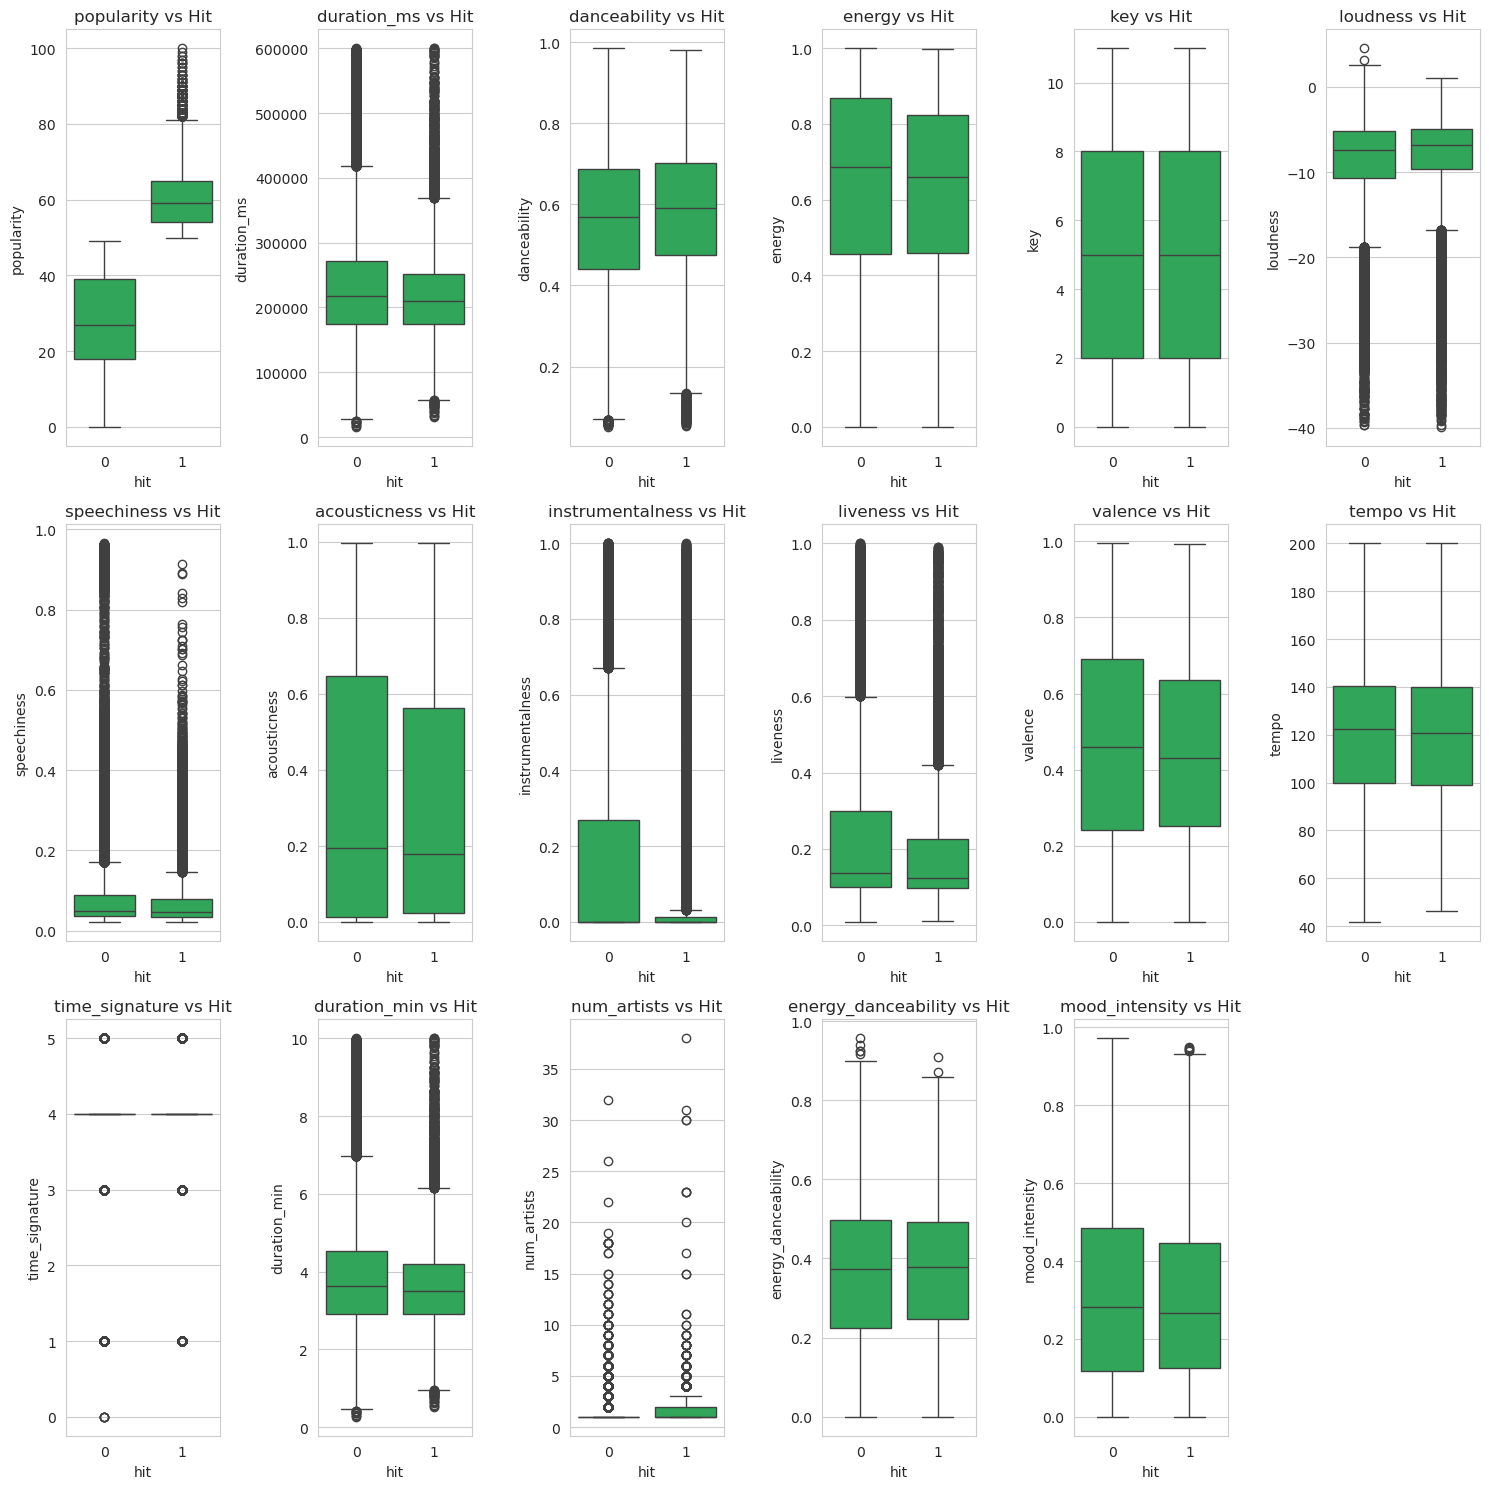

In [49]:
# Numerical variables vs Target
n_cols = 6
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='hit', y=col, data=df_clean, ax=axes[i], color=spotify_green_colour)
    axes[i].set_title(f"{col} vs Hit")

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

“Boxplot analysis reveals that features such as popularity, danceability, energy, and loudness exhibit clear differences between hit and non-hit songs, indicating strong predictive potential. In contrast, variables such as duration, key, and tempo show minimal variation across classes and may contribute limited predictive value.”

                 total_songs  hit_count  hit_rate
genre_group                                      
indie_alt                652        336     0.515
pop                    13697       4924     0.359
rock                    6960       2458     0.353
hiphop_rnb              2206        761     0.345
relax                   4162       1315     0.316
jazz_blues_funk         2138        634     0.297
electronic             13851       3465     0.250
classical               2233        547     0.245
folk_country            5201       1130     0.217
metal                   5594       1093     0.195
dance                   4214        818     0.194
other                   5216        989     0.190
kids                    4382        675     0.154
latin                   7276        786     0.108
reggae_afro             2455        228     0.093


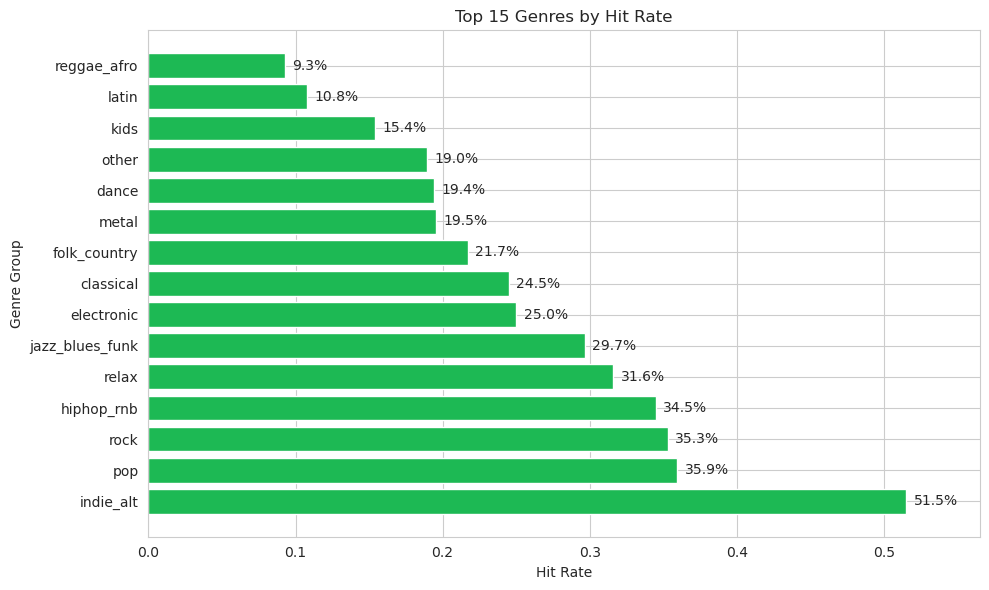

In [50]:
# Categorical vs Target
hit_rate_genre = (df_clean.groupby('genre_group').agg(total_songs=('hit', 'count'),
                                                      hit_count=('hit', 'sum'),
                                                      hit_rate=('hit', 'mean')).sort_values('hit_rate', ascending=False))

# only keep genres with enough songs to make comparison fair
min_songs = 50
hit_rate_genre_filtered = hit_rate_genre[hit_rate_genre['total_songs'] >= min_songs]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(hit_rate_genre_filtered.index, hit_rate_genre_filtered['hit_rate'], color=spotify_green_colour)

# Add labels
for i, v in enumerate(hit_rate_genre_filtered['hit_rate']):
    plt.text(v + 0.005, i, f"{v:.1%}", va='center')

print(hit_rate_genre_filtered.sort_values('hit_rate', ascending=False).head(15))

plt.title(f"Top {top_n} Genres by Hit Rate")
plt.xlabel('Hit Rate')
plt.ylabel('Genre Group')
plt.xlim(0, hit_rate_genre_filtered['hit_rate'].max() + 0.05)
plt.tight_layout()
plt.show()

## **4. Preprocessing for Machine Learning Modelling**

In [51]:
df_model = df_clean.copy()

In [52]:
df_model.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'duration_min',
       'num_artists', 'is_collab', 'energy_danceability', 'mood_intensity',
       'genre_group', 'hit'],
      dtype='object')

In [53]:
# Double check missing values
df_model.isnull().sum()

track_id               0
artists                0
album_name             0
track_name             0
popularity             0
duration_ms            0
explicit               0
danceability           0
energy                 0
key                    0
loudness               0
mode                   0
speechiness            0
acousticness           0
instrumentalness       0
liveness               0
valence                0
tempo                  0
time_signature         0
track_genre            0
duration_min           0
num_artists            0
is_collab              0
energy_danceability    0
mood_intensity         0
genre_group            0
hit                    0
dtype: int64

In [54]:
# Avoid leakage
df_model = df_model.drop(columns=['popularity'])

### ***4.1 Target and Features selections***

In [55]:
target_col = 'hit'

In [56]:
features = [
    'loudness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'danceability',
    'energy',
    'valence',
    'mood_intensity',
    'genre_group'
]

In [57]:
drop_cols = [col for col in df_model.columns 
             if col not in features + [target_col]]

df_model = df_model.drop(columns=drop_cols, errors='ignore')
print(f'Columns kept: {df_model.columns.tolist()}')

Columns kept: ['danceability', 'energy', 'loudness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'mood_intensity', 'genre_group', 'hit']


### ***4.2 Data Validation***

In [58]:
from sklearn.model_selection import train_test_split

def split_df(dataframe, seed=42, percentage=0.7):

    X = dataframe[features]
    y = dataframe[target_col]
    
    return train_test_split(X,
                            y,
                            test_size=1-percentage,
                            random_state=seed,
                            stratify=y)

X_train, X_test, y_train, y_test = split_df(df_model)

In [59]:
from collections import Counter

def class_perc(data):
    lendata = len(data)
    classes = Counter(data)
    
    for sclass, freq in classes.items():
        perc = (freq / lendata) * 100
        print(f"Class '{sclass}': {perc:.2f}%")
        
print('Training data set: ', X_train.shape)
print('Testing data set: ', X_test.shape)

class_perc(y_train.to_frame(name=target)[target])
class_perc(y_test.to_frame(name=target)[target])

Training data set:  (56165, 9)
Testing data set:  (24072, 9)
Class '0': 74.88%
Class '1': 25.12%
Class '0': 74.88%
Class '1': 25.12%


## **5. Classification Model - Option 1: Classification Tree**

### ***5.1 Creating the Preprocessing Pipeline***

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),  # removed add_indicator=True
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre  = preprocessor.transform(X_test) 

new_cols = preprocessor.get_feature_names_out()
X_train = pd.DataFrame(X_train_pre, columns=new_cols, index=X_train.index)
X_test  = pd.DataFrame(X_test_pre,  columns=new_cols, index=X_test.index)

We fit the preprocessor on training data only to avoid data leakage.
- `remainder='passthrough'` ensures no columns are dropped
- `add_indicator=True` flags any imputed values as a separate feature

In [61]:
print(f"X_train shape after preprocessing: {X_train.shape}")
X_train.head()

X_train shape after preprocessing: (56165, 23)


,loudness,acousticness,instrumentalness,liveness,danceability,energy,valence,mood_intensity,genre_group_classical,genre_group_dance,genre_group_electronic,genre_group_folk_country,genre_group_hiphop_rnb,genre_group_indie_alt,genre_group_jazz_blues_funk,genre_group_kids,genre_group_latin,genre_group_metal,genre_group_other,genre_group_pop,genre_group_reggae_afro,genre_group_relax,genre_group_rock
60680,-4.267,0.000,0.932,0.066,0.298,0.937,0.806,0.755,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000
27612,-8.479,0.230,0.000,0.100,0.613,0.519,0.270,0.140,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
13042,-13.108,0.894,0.000,0.157,0.657,0.192,0.305,0.059,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
68535,-5.115,0.001,0.806,0.096,0.476,0.957,0.309,0.296,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
70166,-3.932,0.000,0.842,0.269,0.235,0.965,0.111,0.107,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000


### ***5.2 Building the initial Classification Tree and evaluating performance***

**Notes to prof:** We first grow a fully unconstrained tree using Entropy (or Information Gain) as the splitting criterion and `class_weight="balanced"` to handle class imbalance. We expect overfitting here

In [62]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import set_config
set_config(display='diagram')

my_tree = DecisionTreeClassifier(criterion='entropy',
                                 random_state=42,
                                 class_weight='balanced')

measure = 'recall'

my_tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       random_state=42)

In [63]:
metrics_map = {'recall': recall_score,
               'precision': precision_score,
               'f1': f1_score}

pred_train = my_tree.predict(X_train)
score1 = metrics_map[measure](y_train, pred_train)
print(f"{measure} of training set = {score1:.2%}")

pred_test = my_tree.predict(X_test)
score2 = metrics_map[measure](y_test, pred_test)
print(f"{measure} of testing set  = {score2:.2%}")

recall of training set = 99.99%
recall of testing set  = 37.67%


In [64]:
print('Number of nodes:', my_tree.tree_.node_count)
print('Number of leaves:', my_tree.get_n_leaves())
print('Depth:', my_tree.get_depth())

Number of nodes: 21455
Number of leaves: 10728
Depth: 74


As shown in the recall values and the number of nodes and leaves, it is evident that the initial tree is very deep and clearly overfitting. This requires pruning. We will also inspect the features to determine which tree finds most useful before pruning.

### ***5.3 Pruning the tree***

GridSearchCV will be used to reduce the `max_depth` and `min_samples_leaf`. Should overfitting still persist, Cost Complexity Pruning (CCP) will be explored to penalise branches with low Information Gain.

The GridSearch below was optimised using F1-score to avoid degenerate solutions where the model trivialling maximises recall by predicting all observations as hits.

In [65]:
# Using 5-fold cross-validation
from sklearn.model_selection import GridSearchCV

my_tree_gs = DecisionTreeClassifier(
    random_state=42,
    criterion='entropy',
    class_weight='balanced'
)

param_grid = {
    'max_depth':        [8, 10, 12, 14],
    'min_samples_leaf': [1, 5, 20]
}

tree_pruned_cv = GridSearchCV(
    my_tree_gs,
    param_grid,
    scoring='f1',              
    refit=True,
    return_train_score=True,
    cv=5,
    n_jobs=-1,
    verbose=1
)

tree_pruned_cv.fit(X_train, y_train)

print('Best parameters found:')
print(tree_pruned_cv.best_params_)
print(f'Best F1 on training CV: {tree_pruned_cv.best_score_:.3f}')
print(f'Number of leaves: {tree_pruned_cv.best_estimator_.get_n_leaves()}')
print(f'Depth: {tree_pruned_cv.best_estimator_.get_depth()}')
print(f'Unique prob values: {len(np.unique(tree_pruned_cv.predict_proba(X_test)[:,1]))}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters found:
{'max_depth': 14, 'min_samples_leaf': 20}
Best F1 on training CV: 0.484
Number of leaves: 647
Depth: 14
Unique prob values: 337


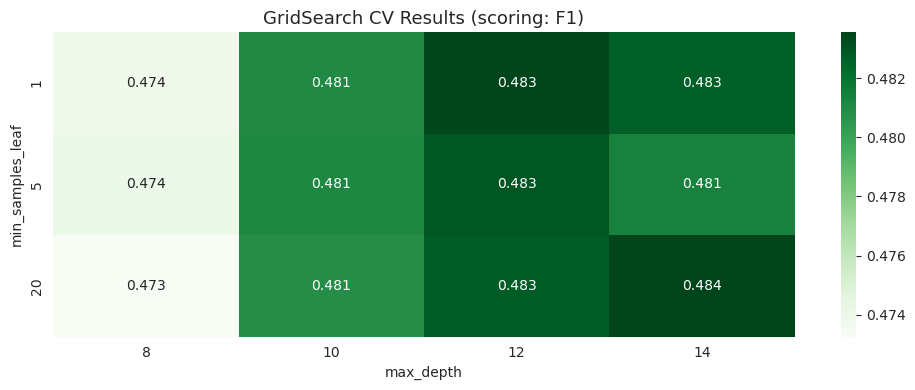

In [66]:
results_gs = pd.DataFrame(tree_pruned_cv.cv_results_)
results_gs = results_gs[['param_max_depth', 'param_min_samples_leaf', 'mean_test_score']]
results_gs.columns = ['max_depth', 'min_samples_leaf', 'f1']

pivot_table = results_gs.pivot(index='min_samples_leaf', columns='max_depth', values='f1')

plt.figure(figsize=(10, 4))
sns.heatmap(pivot_table, annot=True, cmap='Greens', fmt='.3f')
plt.title('GridSearch CV Results (scoring: F1)', fontsize=13)
plt.xlabel('max_depth')
plt.ylabel('min_samples_leaf')
plt.tight_layout()
plt.savefig('gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Optimal cutoff: 0.52


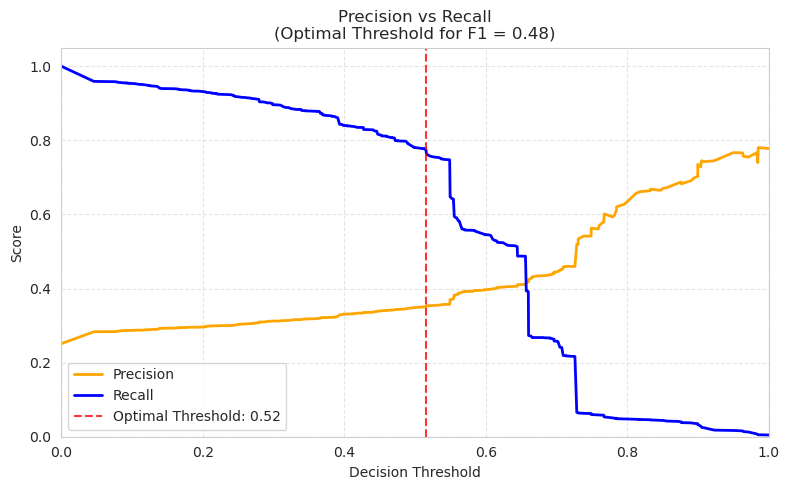

In [67]:
# Determining the optimal threshold through comparing Precision vs Recall
prob_pred = tree_pruned_cv.predict_proba(X_test)[:, 1]
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, prob_pred)
f1_scores_thresh = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-12)
best_idx = np.argmax(f1_scores_thresh)
best_threshold = thresholds[best_idx]

cutoff = best_threshold

print(f"Optimal cutoff: {cutoff:.2f}")
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precision_vals[:-1], color='orange', label='Precision', linewidth=2)
ax.plot(thresholds, recall_vals[:-1],    color='blue',   label='Recall',    linewidth=2)
ax.axvline(best_threshold, color='red', linestyle='--', alpha=0.8,
           label=f'Optimal Threshold: {best_threshold:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Precision vs Recall\n(Optimal Threshold for F1 = {f1_scores_thresh[best_idx]:.2f})', fontsize=12)
ax.legend(loc='lower left')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
# Check for overfitting
def Overfitting_test(tree_model, cutoff=0.5):
    probs_train = tree_model.predict_proba(X_train)[:, 1]
    probs_test  = tree_model.predict_proba(X_test)[:, 1]
    preds_train = (probs_train >= cutoff).astype(int)
    preds_test  = (probs_test  >= cutoff).astype(int)

    metrics_comparison = {
        'Metric': ['ROC AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score'],
        'Train Set': [
            roc_auc_score(y_train, probs_train),
            accuracy_score(y_train, preds_train),
            precision_score(y_train, preds_train, zero_division=0),
            recall_score(y_train, preds_train),
            f1_score(y_train, preds_train)
        ],
        'Test Set': [
            roc_auc_score(y_test, probs_test),
            accuracy_score(y_test, preds_test),
            precision_score(y_test, preds_test, zero_division=0),
            recall_score(y_test, preds_test),
            f1_score(y_test, preds_test)
        ]
    }

    df_metrics = pd.DataFrame(metrics_comparison).set_index('Metric')
    df_metrics['Difference (Test - Train)'] = df_metrics['Test Set'] - df_metrics['Train Set']
    return df_metrics

tree_pruned = tree_pruned_cv.best_estimator_

df_final = Overfitting_test(tree_pruned, cutoff=cutoff)
df_final.index.name = None
print(f'At optimal cutoff ({cutoff:.2f}):')
df_final.style.format('{:.2%}').background_gradient(subset=['Difference (Test - Train)'], cmap='Greens')

At optimal cutoff (0.52):


,Train Set,Test Set,Difference (Test - Train)
ROC AUC,75.75%,69.41%,-6.35%
Accuracy,62.08%,58.40%,-3.68%
Precision,38.28%,35.14%,-3.13%
Recall,83.15%,77.58%,-5.58%
F1-Score,52.42%,48.37%,-4.05%


While the differences between the predictive performance of the Train and Test dataset are minimal and therefore show no signs of overfitting, it is important to note that Precision and F1-Score are low at around 35-38% and 48-52% respectively, which thus indicate low predictive performance.

At optimal cutoff (0.52):


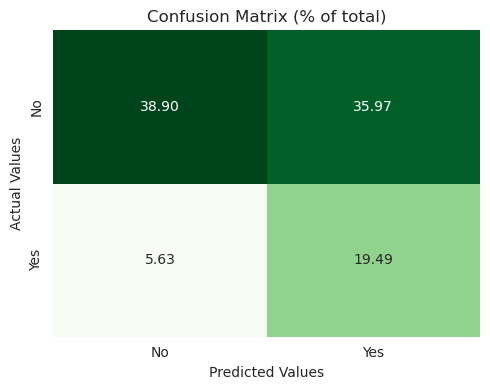

              precision    recall  f1-score   support

          No       0.87      0.52      0.65     18024
         Yes       0.35      0.78      0.48      6048

    accuracy                           0.58     24072
   macro avg       0.61      0.65      0.57     24072
weighted avg       0.74      0.58      0.61     24072



In [69]:
# Confusion Matrix
probs_grid = tree_pruned.predict_proba(X_test)[:, 1]
preds_grid = (probs_grid >= cutoff).astype(int)

test_conf_matrix = confusion_matrix(y_test, preds_grid)
test_conf_matrix_pct = test_conf_matrix.astype('float') / test_conf_matrix.sum() * 100
test_conf_matrix_pct = np.round(test_conf_matrix_pct, 2)
labels = ['No', 'Yes']

print(f'At optimal cutoff ({cutoff:.2f}):')
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(test_conf_matrix_pct, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=labels, yticklabels=labels, cbar=False)
ax.set_title('Confusion Matrix (% of total)')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values')
plt.tight_layout()
plt.savefig('confusion_matrix_tree.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, preds_grid, target_names=['No', 'Yes']))

## **6. Classification Model - Option 2: Random Forest**

While the Classification Tree provides an interpretable baseline, it suffers from high variance — small changes in the training data can produce very different trees. This instability, combined with limited predictive performance, motivates the exploration of ensemble  methods.

**Random Forest** addresses this: instead of growing one tree, it trains multiple trees on random bootstrap samples of the training data and aggregates their predictions by majority vote. This reduces variance without increasing bias. The use of Random Forest over Bagging also ensures that no dominant feature appear in every tree and ensures that each tree captures a different aspect of the data, enabling more robust results and thus better generalisation to unseen data. 

In [70]:
import time

baseRF = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    max_features='sqrt',
    oob_score=True,
    class_weight='balanced_subsample'
)

rf_params = {
    'max_features':     ['sqrt', 'log2'],
    'max_depth':        [8, 10, 12],      
    'min_samples_leaf': [5, 10, 20]       
}

start_time = time.time()
cvRF = GridSearchCV(estimator=baseRF,
                    param_grid=rf_params,
                    cv=3, scoring=measure, 
                    verbose=1, n_jobs=-1)
cvRF.fit(X_train, y_train)

print(f'Completed in {(time.time() - start_time):.2f} seconds')
print(f'Best RF parameters for {measure}: {cvRF.best_params_}')

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Completed in 38.05 seconds
Best RF parameters for recall: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 20}


In [71]:
def evaluate_model_performance(cv_obj, X_tr, y_tr, metric_name='recall', cutoff=0.5):
    metrics_map = {'recall': recall_score, 'precision': precision_score, 'f1': f1_score}
    metric_func  = metrics_map[metric_name.lower()]
    model        = cv_obj.best_estimator_
    train_result = metric_func(y_tr, model.predict(X_tr))
    oob_probs    = model.oob_decision_function_[:, 1]
    oob_preds    = (oob_probs >= cutoff).astype(int)
    oob_result   = metric_func(y_tr, oob_preds)
    cv_result    = cv_obj.best_score_
    print(f'--- {metric_name.upper()} COMPARATIVE REPORT (at default cutoff) ---')
    print(f'1. Train Set (In-Bag):     {train_result:.1%}')
    print(f'2. OOB Set (Internal Val): {oob_result:.1%}')
    print(f'3. CV Score (GridSearch):  {cv_result:.1%}')
    gap = train_result - oob_result
    print(f'\nOverfitting Gap (Train - OOB): {gap:.1%}')
    print('>> Overfitting detected.' if gap > 0.10 else '>> Model is consistent and robust.')

evaluate_model_performance(cvRF, X_train, y_train, measure)

--- RECALL COMPARATIVE REPORT (at default cutoff) ---
1. Train Set (In-Bag):     74.4%
2. OOB Set (Internal Val): 72.3%
3. CV Score (GridSearch):  72.3%

Overfitting Gap (Train - OOB): 2.1%
>> Model is consistent and robust.


OOB Recall for 30 trees: 0.7121
OOB Recall for 40 trees: 0.7259
OOB Recall for 50 trees: 0.7231
OOB Recall for 60 trees: 0.7207
OOB Recall for 70 trees: 0.7227
OOB Recall for 80 trees: 0.7282
OOB Recall for 90 trees: 0.7290
OOB Recall for 100 trees: 0.7290
OOB Recall for 110 trees: 0.7301
OOB Recall for 120 trees: 0.7287
OOB Recall for 130 trees: 0.7294
OOB Recall for 140 trees: 0.7315
OOB Recall for 150 trees: 0.7305
OOB Recall for 160 trees: 0.7308
OOB Recall for 170 trees: 0.7308
OOB Recall for 180 trees: 0.7309
OOB Recall for 190 trees: 0.7299
OOB Recall for 200 trees: 0.7291


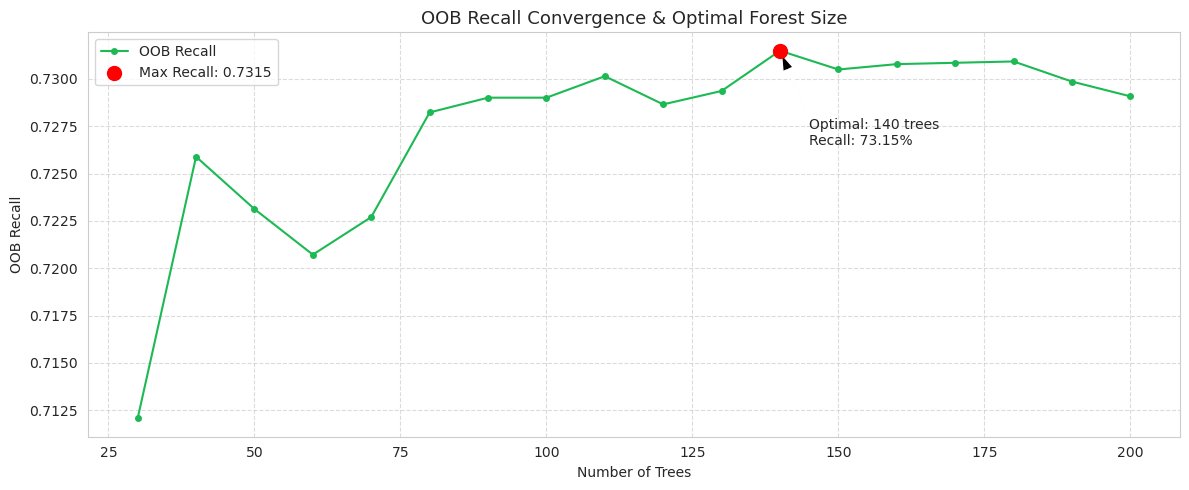

Optimal number of trees: 140


In [72]:
# Determining optimal number of trees
oob_recall_scores = []
estimator_range   = range(30, 201, 10)  # start from 30, covers relevant range

for n_est in estimator_range:
    m = RandomForestClassifier(
        n_estimators=n_est,
        random_state=42,
        max_features=cvRF.best_params_['max_features'],
        max_depth=cvRF.best_params_['max_depth'],
        min_samples_leaf=cvRF.best_params_['min_samples_leaf'],
        class_weight='balanced_subsample',
        oob_score=True, n_jobs=-1
    )
    m.fit(X_train, y_train)
    oob_preds = m.oob_decision_function_.argmax(axis=1)
    oob_recall_scores.append(recall_score(y_train, oob_preds))
    print(f'OOB Recall for {n_est} trees: {oob_recall_scores[-1]:.4f}')

opt_trees  = list(estimator_range)[np.argmax(oob_recall_scores)]
max_recall = max(oob_recall_scores)

plt.figure(figsize=(12, 5))
plt.plot(estimator_range, oob_recall_scores, marker='o', markersize=4,
         color=spotify_green_colour, label='OOB Recall')
plt.scatter(opt_trees, max_recall, color='red', s=100, zorder=5,
            label=f'Max Recall: {max_recall:.4f}')
plt.annotate(f'Optimal: {opt_trees} trees\nRecall: {max_recall:.2%}',
             xy=(opt_trees, max_recall),
             xytext=(opt_trees + 5, max_recall - 0.005),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))
plt.xlabel('Number of Trees'); plt.ylabel('OOB Recall')
plt.title('OOB Recall Convergence & Optimal Forest Size', fontsize=13)
plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('rf_optimal_trees.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Optimal number of trees: {opt_trees}')

In [73]:
# Final Random Forest model
final_rf = RandomForestClassifier(
    n_estimators=opt_trees,
    random_state=42,
    max_features=cvRF.best_params_['max_features'],
    max_depth=cvRF.best_params_['max_depth'],
    min_samples_leaf=cvRF.best_params_['min_samples_leaf'],
    class_weight='balanced_subsample',
    oob_score=True, n_jobs=-1
)

final_rf.fit(X_train, y_train)
print(f'RF Recall at default cutoff (0.50): {recall_score(y_test, final_rf.predict(X_test)):.1%}')

RF Recall at default cutoff (0.50): 73.5%


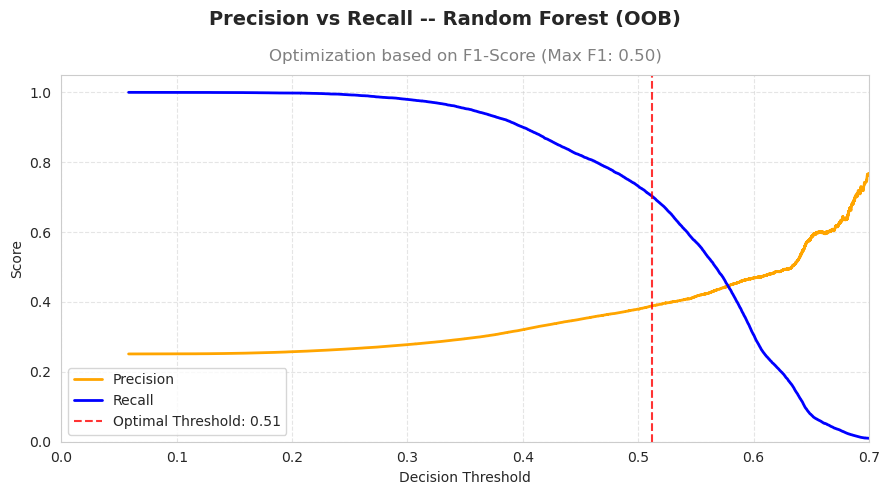

Optimal cutoff: 0.51


In [74]:
# Determine the optimal threshold through comparing Precision vs Recall
oob_probs_rf = final_rf.oob_decision_function_[:, 1]
prec_rf, rec_rf, thr_rf = precision_recall_curve(y_train, oob_probs_rf)
f1_rf       = 2*(prec_rf[:-1]*rec_rf[:-1])/(prec_rf[:-1]+rec_rf[:-1]+1e-12)
best_idx_rf = np.argmax(f1_rf)
cutoff_rf   = thr_rf[best_idx_rf]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thr_rf, prec_rf[:-1], color='orange', label='Precision', linewidth=2)
ax.plot(thr_rf, rec_rf[:-1],  color='blue',   label='Recall',    linewidth=2)
ax.axvline(cutoff_rf, color='red', linestyle='--', alpha=0.8,
           label=f'Optimal Threshold: {cutoff_rf:.2f}')
ax.set_xlabel('Decision Threshold'); ax.set_ylabel('Score')
ax.set_title(f'Optimization based on F1-Score (Max F1: {f1_rf[best_idx_rf]:.2f})',
             fontsize=12, pad=10, color='gray')
plt.suptitle('Precision vs Recall -- Random Forest (OOB)', fontsize=14, fontweight='bold')
ax.legend(loc='lower left'); ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim([0,0.7]); ax.set_ylim([0,1.05])
plt.tight_layout()
plt.savefig('rf_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Optimal cutoff: {cutoff_rf:.2f}')

In [75]:
# Check for overfitting
prob_pred_rf  = final_rf.predict_proba(X_test)[:, 1]
df_rf_overfit = Overfitting_test(final_rf, cutoff=cutoff_rf)
df_rf_overfit.index.name = None

print(f'At optimal cutoff ({cutoff_rf:.2f}):')
df_rf_overfit.style.format('{:.2%}').background_gradient(
    subset=['Difference (Test - Train)'], cmap='Greens')

At optimal cutoff (0.51):


,Train Set,Test Set,Difference (Test - Train)
ROC AUC,74.17%,72.01%,-2.17%
Accuracy,65.70%,64.31%,-1.39%
Precision,39.93%,38.50%,-1.43%
Recall,72.45%,70.37%,-2.08%
F1-Score,51.49%,49.77%,-1.72%


At optimal cutoff (0.51):


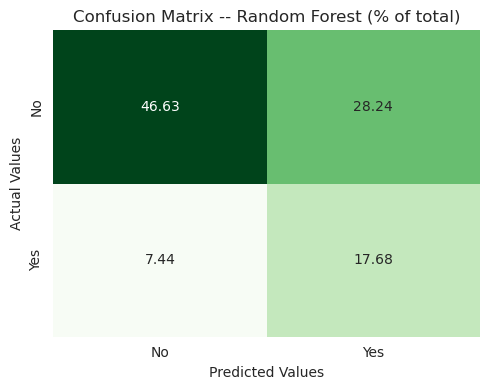

              precision    recall  f1-score   support

          No       0.86      0.62      0.72     18024
         Yes       0.38      0.70      0.50      6048

    accuracy                           0.64     24072
   macro avg       0.62      0.66      0.61     24072
weighted avg       0.74      0.64      0.67     24072



In [76]:
preds_rf_cut = (prob_pred_rf >= cutoff_rf).astype(int)
cm_rf        = confusion_matrix(y_test, preds_rf_cut)
cm_rf_pct    = np.round(cm_rf.astype('float') / cm_rf.sum() * 100, 2)

print(f'At optimal cutoff ({cutoff_rf:.2f}):')
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_rf_pct, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'], cbar=False)
ax.set_title('Confusion Matrix -- Random Forest (% of total)')
ax.set_xlabel('Predicted Values'); ax.set_ylabel('Actual Values')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_test, preds_rf_cut, target_names=['No','Yes']))

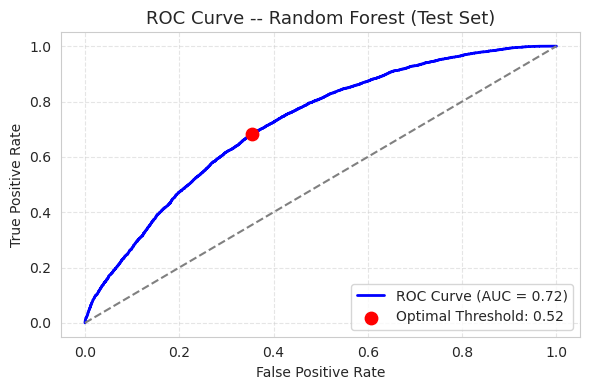

ROC AUC: 0.7201


In [77]:
# ROC Curve
fpr_rf, tpr_rf, thr_roc_rf = roc_curve(y_test, prob_pred_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
opt_idx_rf = np.argmax(tpr_rf - fpr_rf)

plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_rf:.2f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.scatter(fpr_rf[opt_idx_rf], tpr_rf[opt_idx_rf], color='red', s=80, zorder=5,
            label=f'Optimal Threshold: {thr_roc_rf[opt_idx_rf]:.2f}')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve -- Random Forest (Test Set)', fontsize=13)
plt.legend(loc='lower right'); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('rf_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'ROC AUC: {roc_auc_rf:.4f}')

## **7. Classification Model - Option 3: Boosting**

In [78]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

base_xgb = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    scale_pos_weight=scale_pos_weight
)

xgb_params = {
    'max_depth':        [3, 5],
    'learning_rate':    [0.05, 0.1],
    'n_estimators':     [200],
    'subsample':        [0.8],
    'colsample_bytree': [0.5, 0.8],
    'min_child_weight': [10, 20]
}

start_time = time.time()
cvXGB = GridSearchCV(
    estimator=base_xgb,
    param_grid=xgb_params,
    cv=3, scoring=measure,
    n_jobs=-1, verbose=1
)
cvXGB.fit(X_train, y_train)

print(f'Completed in {(time.time() - start_time):.2f} seconds')
print(f'Best XGBoost parameters for {measure}: {cvXGB.best_params_}')

scale_pos_weight: 2.98
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Completed in 8.80 seconds
Best XGBoost parameters for recall: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 20, 'n_estimators': 200, 'subsample': 0.8}


In [79]:
def evaluate_xgb_performance(cv_obj, X_tr, y_tr, X_te, y_te, metric_name='recall'):
    metrics_map = {'recall': recall_score, 'precision': precision_score, 'f1': f1_score}
    metric_func  = metrics_map[metric_name.lower()]
    model        = cv_obj.best_estimator_
    train_result = metric_func(y_tr, model.predict(X_tr))
    test_result  = metric_func(y_te, model.predict(X_te))
    cv_result    = cv_obj.best_score_
    print(f'--- {metric_name.upper()} COMPARATIVE REPORT (XGBoost) ---')
    print(f'1. Train Set:  {train_result:.1%}')
    print(f'2. CV Score:   {cv_result:.1%}')
    print(f'3. Test Set:   {test_result:.1%}')
    gap = train_result - test_result
    print(f'\nOverfitting Gap (Train - Test): {gap:.1%}')
    print('>> Overfitting detected.' if gap > 0.10 else '>> Model is consistent and robust.')

evaluate_xgb_performance(cvXGB, X_train, y_train, X_test, y_test, measure)

--- RECALL COMPARATIVE REPORT (XGBoost) ---
1. Train Set:  76.0%
2. CV Score:   72.5%
3. Test Set:   73.6%

Overfitting Gap (Train - Test): 2.4%
>> Model is consistent and robust.


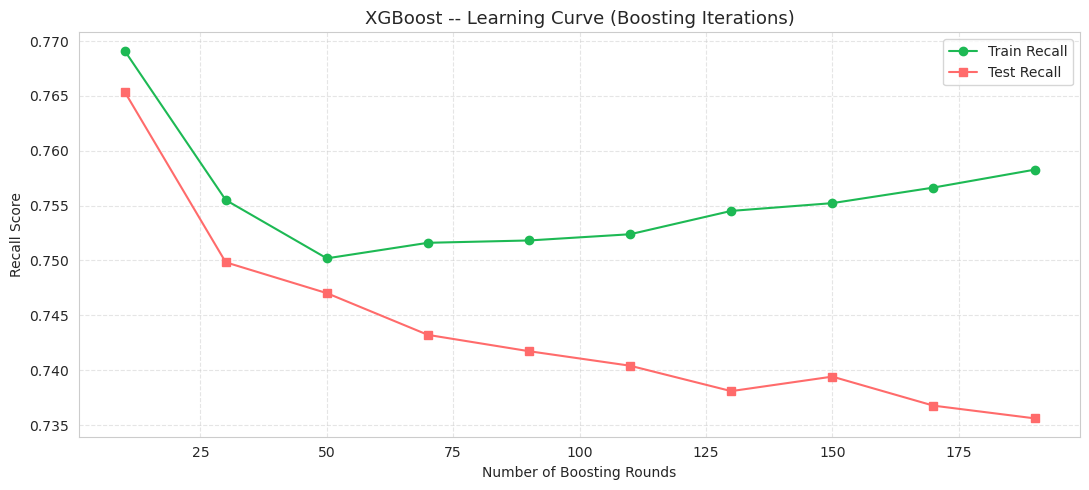

In [80]:
# Learning curve — recall across boosting rounds
estimator_range_xgb  = range(10, cvXGB.best_params_['n_estimators']+10, 20)
train_scores_xgb, test_scores_xgb = [], []

for n in estimator_range_xgb:
    xgb_tmp = XGBClassifier(
        objective='binary:logistic', random_state=42,
        eval_metric='logloss', verbosity=0,
        scale_pos_weight=scale_pos_weight,
        max_depth=cvXGB.best_params_['max_depth'],
        learning_rate=cvXGB.best_params_['learning_rate'],
        n_estimators=n,
        subsample=cvXGB.best_params_['subsample'],
        colsample_bytree=cvXGB.best_params_['colsample_bytree'],
        min_child_weight=cvXGB.best_params_['min_child_weight']
    )
    xgb_tmp.fit(X_train, y_train)
    train_scores_xgb.append(recall_score(y_train, xgb_tmp.predict(X_train)))
    test_scores_xgb.append(recall_score(y_test,   xgb_tmp.predict(X_test)))

plt.figure(figsize=(11, 5))
plt.plot(estimator_range_xgb, train_scores_xgb, 'o-', label='Train Recall', color=spotify_green_colour)
plt.plot(estimator_range_xgb, test_scores_xgb,  's-', label='Test Recall',  color='#FF6B6B')
plt.xlabel('Number of Boosting Rounds'); plt.ylabel('Recall Score')
plt.title('XGBoost -- Learning Curve (Boosting Iterations)', fontsize=13)
plt.legend(); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('xgb_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [81]:
# Final XGBoost model
final_xgb = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss', verbosity=0,
    scale_pos_weight=scale_pos_weight,
    max_depth=cvXGB.best_params_['max_depth'],
    learning_rate=cvXGB.best_params_['learning_rate'],
    n_estimators=cvXGB.best_params_['n_estimators'],
    subsample=cvXGB.best_params_['subsample'],
    colsample_bytree=cvXGB.best_params_['colsample_bytree'],
    min_child_weight=cvXGB.best_params_['min_child_weight']
)
final_xgb.fit(X_train, y_train)

print(f'XGBoost Recall at default cutoff (0.50): {recall_score(y_test, final_xgb.predict(X_test)):.1%}')

XGBoost Recall at default cutoff (0.50): 73.6%


Optimal cutoff: 0.52


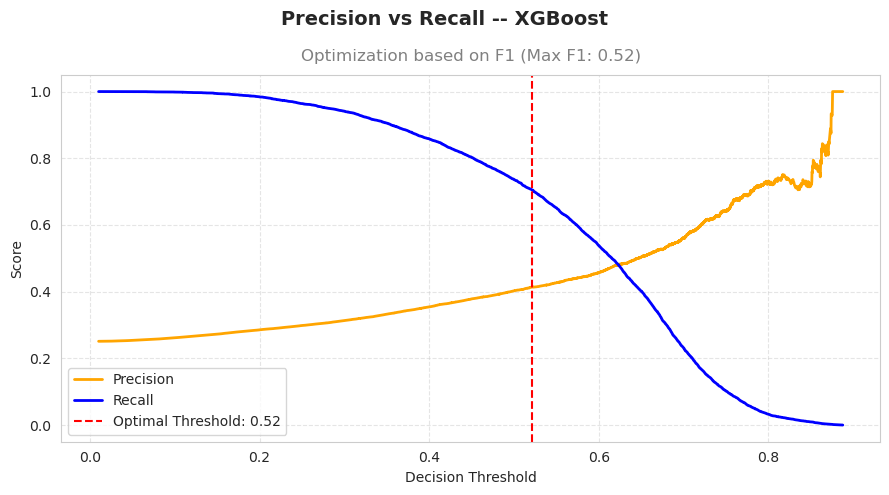

In [82]:
# Optimal threshold — using test set for XGBoost (no OOB available)
prob_pred_xgb = final_xgb.predict_proba(X_test)[:, 1]
prec_xgb, rec_xgb, thr_xgb = precision_recall_curve(y_test, prob_pred_xgb)
f1_xgb     = 2*(prec_xgb[:-1]*rec_xgb[:-1])/(prec_xgb[:-1]+rec_xgb[:-1]+1e-12)
best_idx_x = np.argmax(f1_xgb)
cutoff_xgb = thr_xgb[best_idx_x]

print(f'Optimal cutoff: {cutoff_xgb:.2f}')
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thr_xgb, prec_xgb[:-1], color='orange', label='Precision', linewidth=2)
ax.plot(thr_xgb, rec_xgb[:-1],  color='blue',   label='Recall',    linewidth=2)
ax.axvline(cutoff_xgb, color='red', linestyle='--',
           label=f'Optimal Threshold: {cutoff_xgb:.2f}')
ax.set_xlabel('Decision Threshold'); ax.set_ylabel('Score')
ax.set_title(f'Optimization based on F1 (Max F1: {f1_xgb[best_idx_x]:.2f})',
             fontsize=12, pad=10, color='gray')
plt.suptitle('Precision vs Recall -- XGBoost', fontsize=14, fontweight='bold')
ax.legend(loc='lower left'); ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('xgb_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

In [83]:
# Check for overfitting
df_xgb_overfit = Overfitting_test(final_xgb, cutoff=cutoff_xgb)
df_xgb_overfit.index.name = None
print(f'At optimal cutoff ({cutoff_xgb:.2f}):')
df_xgb_overfit.style.format('{:.2%}').background_gradient(
    subset=['Difference (Test - Train)'], cmap='Greens')

At optimal cutoff (0.52):


,Train Set,Test Set,Difference (Test - Train)
ROC AUC,77.45%,74.80%,-2.65%
Accuracy,68.94%,67.51%,-1.43%
Precision,42.98%,41.40%,-1.58%
Recall,72.39%,70.59%,-1.81%
F1-Score,53.94%,52.19%,-1.75%


At optimal cutoff (0.52):


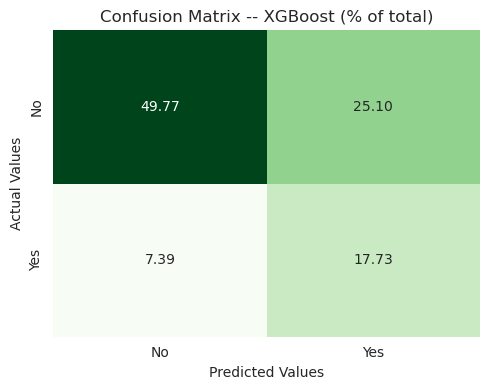

              precision    recall  f1-score   support

          No       0.87      0.66      0.75     18024
         Yes       0.41      0.71      0.52      6048

    accuracy                           0.68     24072
   macro avg       0.64      0.69      0.64     24072
weighted avg       0.76      0.68      0.70     24072



In [84]:
# Confusion matrix
preds_xgb_cut = (prob_pred_xgb >= cutoff_xgb).astype(int)
cm_xgb        = confusion_matrix(y_test, preds_xgb_cut)
cm_xgb_pct    = np.round(cm_xgb.astype('float') / cm_xgb.sum() * 100, 2)

print(f'At optimal cutoff ({cutoff_xgb:.2f}):')
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_xgb_pct, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'], cbar=False)
ax.set_title('Confusion Matrix -- XGBoost (% of total)')
ax.set_xlabel('Predicted Values'); ax.set_ylabel('Actual Values')
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_test, preds_xgb_cut, target_names=['No','Yes']))

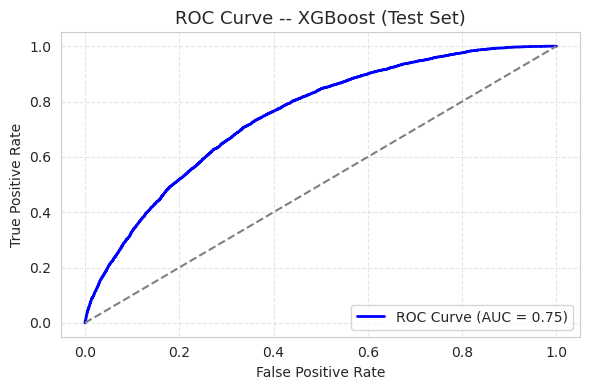

ROC AUC: 0.7480


In [85]:
# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, prob_pred_xgb)
roc_auc_xgb          = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb, tpr_xgb, color='blue', lw=2,
         label=f'ROC Curve (AUC = {roc_auc_xgb:.2f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve -- XGBoost (Test Set)', fontsize=13)
plt.legend(loc='lower right'); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('xgb_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'ROC AUC: {roc_auc_xgb:.4f}')

## **8. Comparing the Classification Models and Final Selection**

We compare all 3 models, prioritising Recall as the primary metric since missing a real hit song (false negative) can be more costly to a record label than promoting a non-hit songs.

In [86]:
def get_all_metrics(y_true, y_prob, cutoff_val, model_name):
    y_pred = (y_prob >= cutoff_val).astype(int)
    return {
        'Model':     model_name,
        'Cutoff':    round(cutoff_val, 2),
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 4)
    }

prob_tree = tree_pruned.predict_proba(X_test)[:, 1]

comparison_df = pd.DataFrame([
    get_all_metrics(y_test, prob_tree,     cutoff,     'Decision Tree'),
    get_all_metrics(y_test, prob_pred_rf,  cutoff_rf,  'Random Forest'),
    get_all_metrics(y_test, prob_pred_xgb, cutoff_xgb, 'XGBoost'),
])

print('FINAL MODEL COMPARISON (each model at optimal F1 threshold)')
print(f'Cutoffs used — DT: {cutoff:.2f} | RF: {cutoff_rf:.2f} | XGB: {cutoff_xgb:.2f}')
print()
print(comparison_df.to_string(index=False))

FINAL MODEL COMPARISON (each model at optimal F1 threshold)
Cutoffs used — DT: 0.52 | RF: 0.51 | XGB: 0.52

        Model  Cutoff  Accuracy  Precision  Recall    F1  ROC-AUC
Decision Tree   0.520     0.584      0.351   0.776 0.484    0.694
Random Forest   0.510     0.643      0.385   0.704 0.498    0.720
      XGBoost   0.520     0.675      0.414   0.706 0.522    0.748


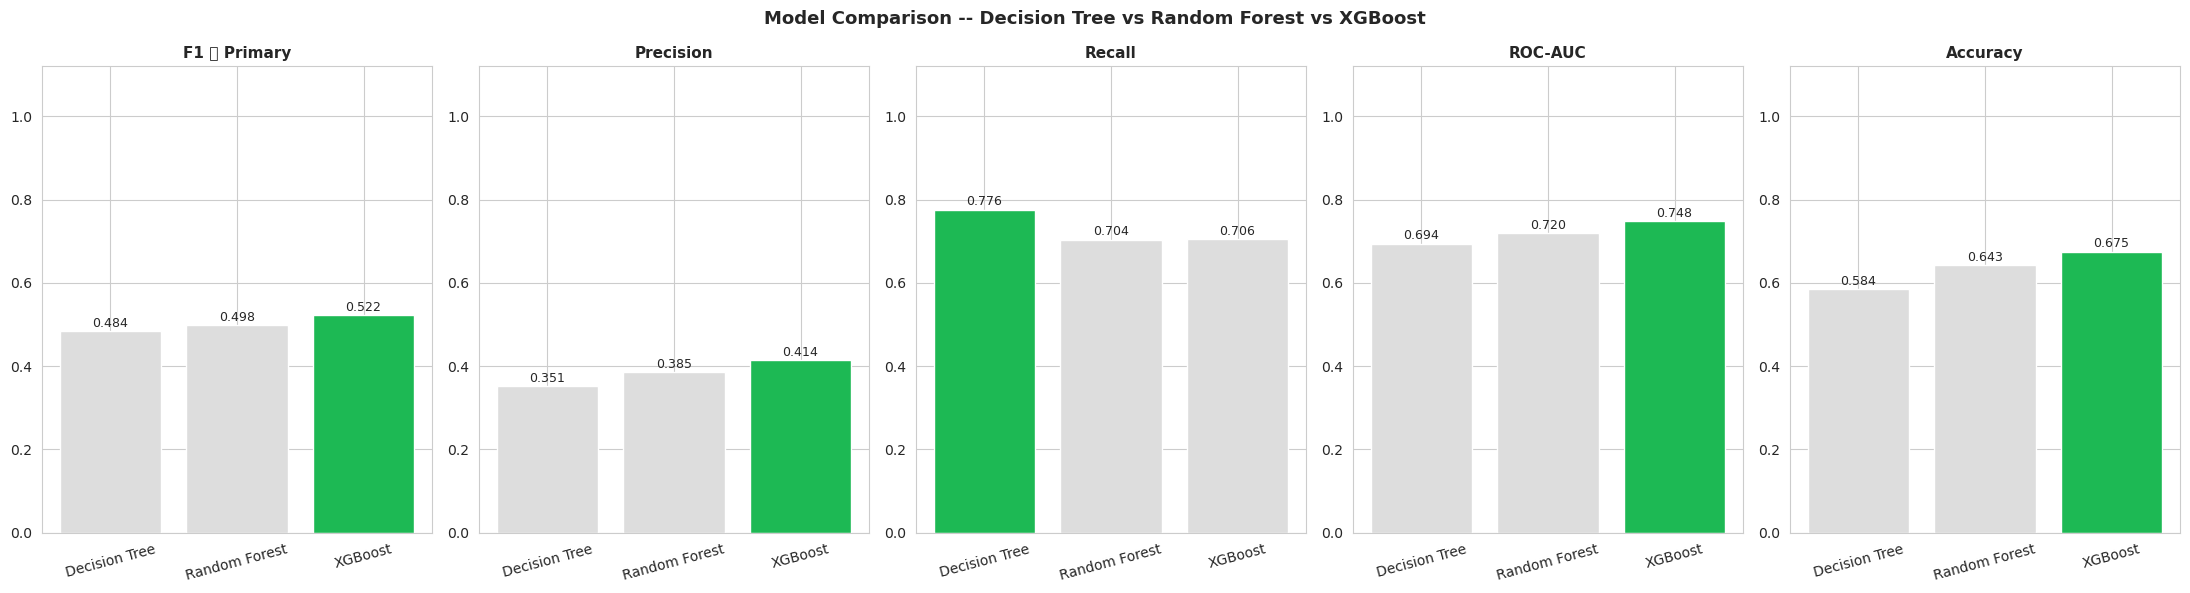

In [87]:
# Plot bar graphs
metrics_to_plot = ['F1', 'Precision', 'Recall', 'ROC-AUC', 'Accuracy']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(22, 6))

for i, metric in enumerate(metrics_to_plot):
    vals       = comparison_df[metric].astype(float)
    # Highest bar always gets spotify green, rest grey
    bar_colors = [spotify_green_colour if vals.iloc[j] == vals.max()
                  else '#dddddd'
                  for j in range(len(vals))]
    bars = axes[i].bar(comparison_df['Model'], vals,
                        color=bar_colors, edgecolor='white')
    title = f'{metric} ⭐ Primary' if metric == 'F1' and i == 0 else metric
    axes[i].set_title(title, fontsize=11, fontweight='bold')
    axes[i].set_ylim(0, 1.12)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison -- Decision Tree vs Random Forest vs XGBoost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_final.png', dpi=150, bbox_inches='tight')
plt.show()

XGBoost is selected as the final model, leading on 4 out of 5 metrics, demonstrating the strongest overall discriminatory power.

While the Decision Tree achieves the highest recall (77.6%), this comes at a precision of only 35.1%, meaning 65% of promoted songs would be non-hits — commercially impractical for most labels with finite promotional budgets. XGBoost achieves comparable recall (70.6%) with meaningfully higher precision (41.4%), offering a better business trade-off between catching genuine hits and avoiding wasted promotions

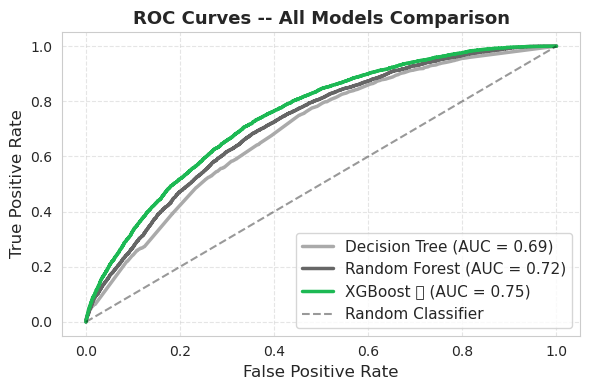

In [88]:
# Combined ROC Curve
fpr_tree, tpr_tree, _ = roc_curve(y_test, prob_tree)
auc_tree               = auc(fpr_tree, tpr_tree)

plt.figure(figsize=(6, 4))
for fpr_v, tpr_v, auc_v, label, color in [
    (fpr_tree, tpr_tree, auc_tree,    'Decision Tree', '#aaaaaa'),  # lighter grey
    (fpr_rf,   tpr_rf,   roc_auc_rf,  'Random Forest', '#666666'),  # darker grey
    (fpr_xgb,  tpr_xgb,  roc_auc_xgb, 'XGBoost ⭐',    spotify_green_colour),
]:
    plt.plot(fpr_v, tpr_v, lw=2.5,
             label=f'{label} (AUC = {auc_v:.2f})', color=color)

plt.plot([0,1],[0,1],'k--', alpha=0.4, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves -- All Models Comparison', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('roc_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

## **9. Business Insights**

### ***9.1 Features importance***

In [89]:
# Select best model
best_model = final_xgb       
best_model_name = 'XGB'

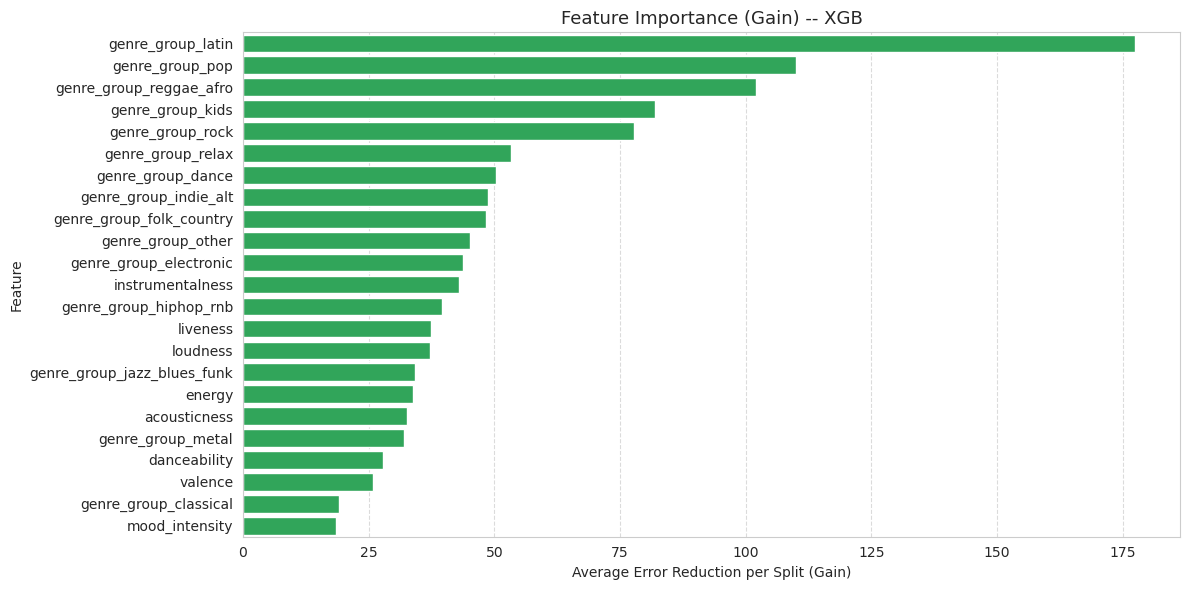

In [90]:
# Feature Importances
imp_dict = best_model.get_booster().get_score(importance_type='gain')
feat_imp = pd.DataFrame(
    list(imp_dict.items()), columns=['Feature', 'Gain']
).sort_values('Gain', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Gain', y='Feature', data=feat_imp, color=spotify_green_colour)
plt.title(f'Feature Importance (Gain) -- {best_model_name}', fontsize=13)
plt.xlabel('Average Error Reduction per Split (Gain)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('best_model_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

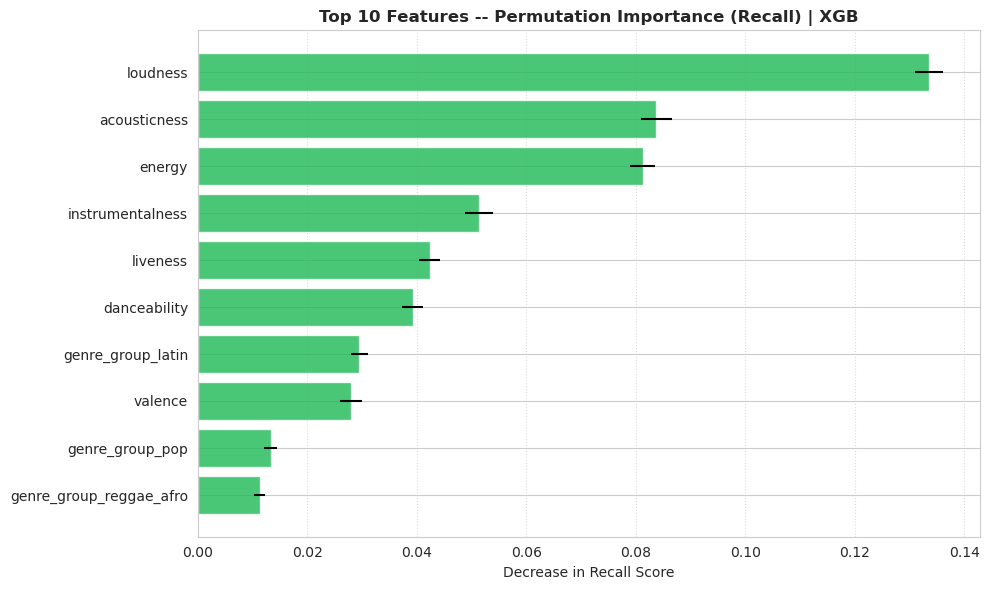

Top predictive features: ['loudness', 'acousticness', 'energy', 'instrumentalness', 'liveness']


In [91]:
# Permutation Importances
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_model, X_train, y_train,
    n_repeats=30, scoring='recall',
    random_state=42, n_jobs=-1
)

df_perm = pd.DataFrame({
    'feature':         X_train.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std':  perm_result.importances_std
})
top10_perm = df_perm.nlargest(10, 'importance_mean').sort_values('importance_mean')

plt.figure(figsize=(10, 6))
plt.barh(top10_perm['feature'], top10_perm['importance_mean'],
         xerr=top10_perm['importance_std'], color=spotify_green_colour, alpha=0.8)
plt.title(f'Top 10 Features -- Permutation Importance (Recall) | {best_model_name}',
          fontsize=12, fontweight='bold')
plt.xlabel('Decrease in Recall Score')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('best_model_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

top_features = top10_perm.sort_values('importance_mean', ascending=False)['feature'].tolist()
print('Top predictive features:', top_features[:5])

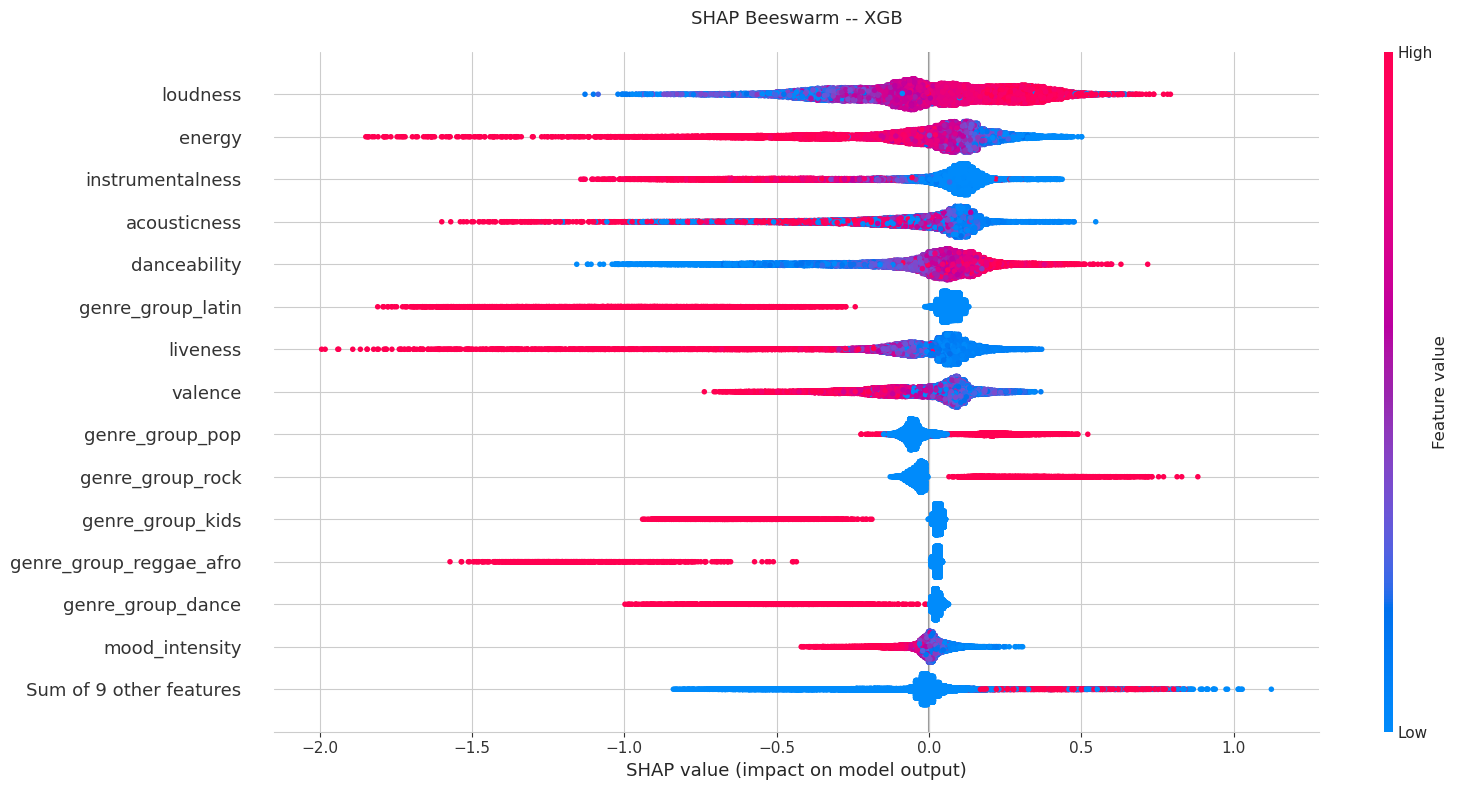

In [92]:
# Plot SHAP
try:
    import shap
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)

    explanation = shap.Explanation(
        values=shap_values,
        base_values=explainer.expected_value,
        data=X_test.values,
        feature_names=X_test.columns.tolist()
    )
    shap.plots.beeswarm(explanation, max_display=15, plot_size=(16, 8), show=False)
    plt.title(f'SHAP Beeswarm -- {best_model_name}', fontsize=13, pad=20)
    plt.tight_layout()
    plt.savefig('best_model_shap.png', dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    print('Run: pip install shap')

### ***9.2 Extracting Examples of Songs***

In [107]:
import pandas as pd

# --------------------------------------------------
# 1. Keep only hit songs and audio features
# --------------------------------------------------
df_score = df_clean[df_clean['hit'] == 1][[
    'track_name', 'artists',
    'loudness', 'danceability', 'energy',
    'acousticness', 'instrumentalness',
    'liveness', 'valence'
]].copy()

# --------------------------------------------------
# 2. Rank each feature based on SHAP direction
#    Rank 1 = most hit-like
# --------------------------------------------------
rank_df = pd.DataFrame(index=df_score.index)

# Higher values are more hit-like
rank_df['rank_loudness'] = df_score['loudness'].rank(ascending=False, method='min')
rank_df['rank_danceability'] = df_score['danceability'].rank(ascending=False, method='min')

# Lower values are more hit-like
rank_df['rank_energy'] = df_score['energy'].rank(ascending=True, method='min')
rank_df['rank_acousticness'] = df_score['acousticness'].rank(ascending=True, method='min')
rank_df['rank_instrumentalness'] = df_score['instrumentalness'].rank(ascending=True, method='min')
rank_df['rank_liveness'] = df_score['liveness'].rank(ascending=True, method='min')
rank_df['rank_valence'] = df_score['valence'].rank(ascending=True, method='min')

# --------------------------------------------------
# 3. Combine rank scores
#    Lower total score = more aligned with hit-like profile
# --------------------------------------------------
df_score['combined_rank_score'] = rank_df.sum(axis=1)

# Optional: overall rank
df_score['overall_rank'] = df_score['combined_rank_score'].rank(method='min')

# --------------------------------------------------
# 4. Extract top 5
# --------------------------------------------------
top5 = (
    df_score
    .sort_values('combined_rank_score', ascending=True)
    .head(5)[[
        'track_name', 'artists',
        'loudness', 'danceability', 'energy',
        'acousticness', 'instrumentalness',
        'liveness', 'valence',
        'combined_rank_score'
    ]]
    .reset_index(drop=True)
)

top5.index = ['#1', '#2', '#3', '#4', '#5']

display(
    top5.style
    .format({
        'loudness': '{:.1f}',
        'danceability': '{:.3f}',
        'energy': '{:.3f}',
        'acousticness': '{:.3f}',
        'instrumentalness': '{:.4f}',
        'liveness': '{:.3f}',
        'valence': '{:.3f}',
        'combined_rank_score': '{:.0f}'
    })
    .background_gradient(subset=['combined_rank_score'], cmap='Greens_r')
    .set_caption('Top 5 Songs — audio-feature rank score (lower combined score = more hit-like)')
)

,track_name,artists,loudness,danceability,energy,acousticness,instrumentalness,liveness,valence,combined_rank_score
#1,Naach Meri Rani,Guru Randhawa;Nikhita Gandhi;Tanishk Bagchi;Nora Fatehi,-5.1,0.676,0.488,0.061,0.0000,0.071,0.151,28229
#2,Moving On,Lil Peep,-5.6,0.821,0.410,0.017,0.0000,0.113,0.197,28587
#3,Thank You,JUNNY,-8.4,0.876,0.473,0.012,0.0000,0.081,0.189,28820
#4,"Turn Down for What (feat. Juicy J, 2 Chainz & French Montana) - Official Remix",DJ Snake;Lil Jon;Juicy J;2 Chainz;French Montana,-4.3,0.822,0.760,0.007,0.0000,0.040,0.362,29245
#5,worthless,eli.,-4.2,0.675,0.530,0.016,0.0000,0.111,0.083,29507


In [109]:
df_score = df_clean[
    df_clean['hit'] == 1
][['track_name', 'artists', 'genre_group',
   'loudness', 'danceability', 'valence',
   'energy', 'acousticness', 'instrumentalness',
   'liveness', 'mood_intensity']].copy()

# One-hot encode genre signals from SHAP
genre_dummies = pd.get_dummies(df_score['genre_group'], prefix='genre_group')
df_score = pd.concat([df_score, genre_dummies], axis=1)

# Ensure all needed columns exist
for col in ['genre_group_pop', 'genre_group_rock', 'genre_group_latin',
            'genre_group_kids', 'genre_group_reggae_afro', 'genre_group_dance']:
    if col not in df_score.columns:
        df_score[col] = 0

# Ranking direction from latest SHAP beeswarm
higher_is_better = [
    'loudness',            # red = RIGHT
    'danceability',        # red = RIGHT
    'valence',             # red = RIGHT
    'mood_intensity',      # red = slightly RIGHT
    'genre_group_pop',     # red = RIGHT
    'genre_group_rock',    # red = RIGHT — updated from rock_alt
]

lower_is_better = [
    'energy',                  # red = LEFT
    'acousticness',            # red = LEFT
    'instrumentalness',        # red = LEFT
    'liveness',                # red = LEFT
    'genre_group_latin',       # red = LEFT
    'genre_group_kids',        # red = LEFT
    'genre_group_reggae_afro', # red = LEFT
    'genre_group_dance',       # red = LEFT
]

rank_df = pd.DataFrame(index=df_score.index)
for feat in higher_is_better:
    if feat in df_score.columns:
        rank_df[feat] = df_score[feat].rank(ascending=False, method='min')
for feat in lower_is_better:
    if feat in df_score.columns:
        rank_df[feat] = df_score[feat].rank(ascending=True, method='min')

df_score['hit_score'] = (
    100 * (1 - (rank_df.sum(axis=1) / (len(df_score) * rank_df.shape[1])))
).round(1)

# Extract top 5
top5 = (df_score
    .sort_values('hit_score', ascending=False)
    .head(5)[['track_name',
               'loudness', 'danceability', 'valence',
               'energy', 'acousticness', 'instrumentalness',
               'liveness', 'mood_intensity', 'hit_score']]
    .reset_index(drop=True)
)

top5.index = ['#1', '#2', '#3', '#4', '#5']

display(top5.style
    .format({
        'loudness':         '{:.1f}',
        'danceability':     '{:.3f}',
        'valence':          '{:.3f}',
        'energy':           '{:.3f}',
        'acousticness':     '{:.3f}',
        'instrumentalness': '{:.4f}',
        'liveness':         '{:.3f}',
        'mood_intensity':   '{:.3f}',
        'hit_score':        '{:.1f}'
    })
    .background_gradient(subset=['hit_score'], cmap='Greens')
    .set_caption('Top 5 Songs — SHAP-aligned composite score (higher = better)')
)

,track_name,loudness,danceability,valence,energy,acousticness,instrumentalness,liveness,mood_intensity,hit_score
#1,Ahora Te Puedes Marchar,-3.0,0.791,0.961,0.722,0.068,0.0000,0.052,0.694,90.7
#2,What Makes You Beautiful,-2.5,0.726,0.888,0.787,0.009,0.0000,0.060,0.699,90.3
#3,Beatbox,-4.2,0.857,0.773,0.700,0.041,0.0000,0.033,0.541,89.7
#4,Gentleman,-3.3,0.878,0.619,0.723,0.002,0.0000,0.052,0.448,89.6
#5,Strawberry Sunscreen,-3.9,0.688,0.909,0.678,0.036,0.0000,0.033,0.616,89.5


### ***9.3 Simulating opportunity costs***

In [98]:
spotify_green = "#1DB954"
black_colour = "black"

def calculate_business_value(y_true, y_proba, threshold, cost_fp, cost_fn, gain_tp):
    """
    Business value per case:
    + gain_tp for correctly identifying a hit (TP)
    - cost_fp for promoting a non-hit (FP)
    - cost_fn for missing a true hit (FN)
    """
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    
    # Ensure 2x2 unpacking
    tn, fp, fn, tp = cm.ravel()
    
    value = ((tp * gain_tp) - (fp * cost_fp) - (fn * cost_fn)) / len(y_true)
    return value


def optimise_threshold(y_train, prob_train, thresholds, cost_fp, cost_fn, gain_tp):
    """
    Find threshold that maximises business value on the training set.
    """
    scores = [
        calculate_business_value(y_train, prob_train, t, cost_fp, cost_fn, gain_tp)
        for t in thresholds
    ]
    
    best_idx = np.argmax(scores)
    best_t = thresholds[best_idx]
    best_val = scores[best_idx]
    
    return best_t, best_val, scores


def evaluate_on_test(y_test, prob_test, threshold, cost_fp, cost_fn, gain_tp):
    """
    Apply chosen threshold to the test set and compute:
    - business value
    - predictions
    - confusion matrix
    """
    y_pred = (prob_test >= threshold).astype(int)
    test_value = calculate_business_value(y_test, prob_test, threshold, cost_fp, cost_fn, gain_tp)
    cm = confusion_matrix(y_test, y_pred)
    
    return y_pred, cm, test_value

In [99]:
# -------------------------------------------------
# Predicted probabilities from your final XGBoost
# -------------------------------------------------
prob_train = final_xgb.predict_proba(X_train)[:, 1]
prob_test  = final_xgb.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0, 1, 500)

# -------------------------------------------------
# Scenario definitions
# -------------------------------------------------
scenario_1 = {
    "name": "Opportunity-Focused",
    "cost_fp": 1000,   # cost of promoting a non-hit
    "cost_fn": 5000,   # cost of missing a true hit
    "gain_tp": 10000   # gain from correctly identifying a hit
}

scenario_2 = {
    "name": "Budget-Control",
    "cost_fp": 4000,   # higher cost of promoting a non-hit
    "cost_fn": 5000,
    "gain_tp": 10000
}

# -------------------------------------------------
# Optimise threshold on TRAIN for both scenarios
# -------------------------------------------------
best_t_1, best_val_train_1, scores_train_1 = optimise_threshold(
    y_train, prob_train, thresholds,
    scenario_1["cost_fp"], scenario_1["cost_fn"], scenario_1["gain_tp"]
)

best_t_2, best_val_train_2, scores_train_2 = optimise_threshold(
    y_train, prob_train, thresholds,
    scenario_2["cost_fp"], scenario_2["cost_fn"], scenario_2["gain_tp"]
)

# -------------------------------------------------
# Evaluate on TEST
# -------------------------------------------------
pred_test_1, cm_1, test_val_1 = evaluate_on_test(
    y_test, prob_test, best_t_1,
    scenario_1["cost_fp"], scenario_1["cost_fn"], scenario_1["gain_tp"]
)

pred_test_2, cm_2, test_val_2 = evaluate_on_test(
    y_test, prob_test, best_t_2,
    scenario_2["cost_fp"], scenario_2["cost_fn"], scenario_2["gain_tp"]
)

# -------------------------------------------------
# Print summary
# -------------------------------------------------
summary_df = pd.DataFrame({
    "Scenario": [scenario_1["name"], scenario_2["name"]],
    "Cost of Promoting Non-Hit (FP)": [scenario_1["cost_fp"], scenario_2["cost_fp"]],
    "Cost of Missing Hit (FN)": [scenario_1["cost_fn"], scenario_2["cost_fn"]],
    "Gain from Identifying Hit (TP)": [scenario_1["gain_tp"], scenario_2["gain_tp"]],
    "Optimal Threshold": [round(best_t_1, 3), round(best_t_2, 3)],
    "Train Profit per Case": [round(best_val_train_1, 2), round(best_val_train_2, 2)],
    "Test Profit per Case": [round(test_val_1, 2), round(test_val_2, 2)]
})

print(summary_df)

              Scenario  Cost of Promoting Non-Hit (FP)  \
0  Opportunity-Focused                            1000   
1       Budget-Control                            4000   

   Cost of Missing Hit (FN)  Gain from Identifying Hit (TP)  \
0                      5000                           10000   
1                      5000                           10000   

   Optimal Threshold  Train Profit per Case  Test Profit per Case  
0              0.228               1869.560              1821.330  
1              0.455                580.720               437.190  


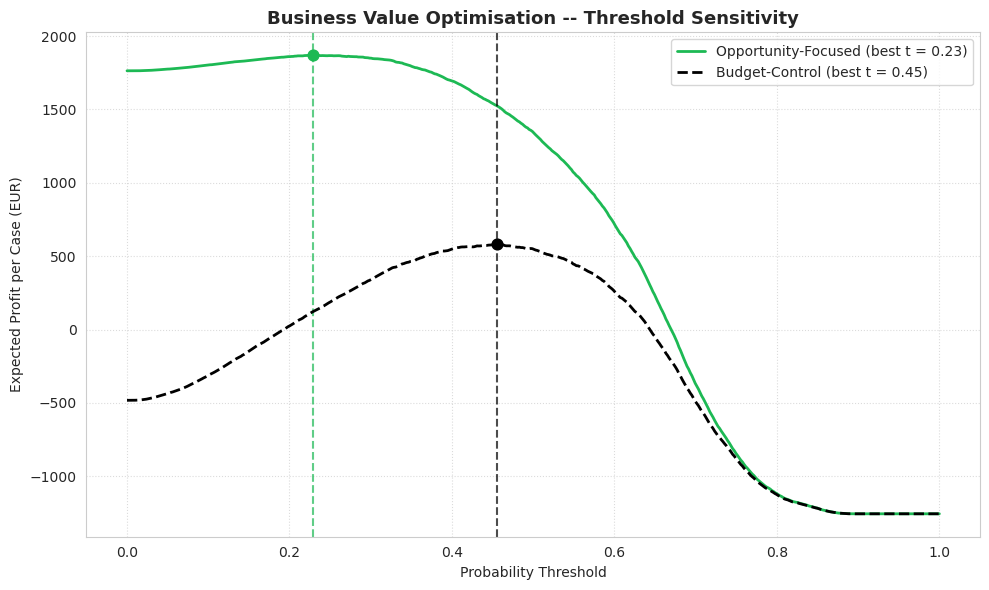

In [100]:
plt.figure(figsize=(10, 6))

# Scenario 1
plt.plot(
    thresholds, scores_train_1,
    color=spotify_green, linewidth=2,
    label=f'{scenario_1["name"]} (best t = {best_t_1:.2f})'
)
plt.scatter(best_t_1, best_val_train_1, color=spotify_green, s=60, zorder=5)
plt.axvline(best_t_1, color=spotify_green, linestyle='--', alpha=0.7)

# Scenario 2
plt.plot(
    thresholds, scores_train_2,
    color=black_colour, linewidth=2, linestyle='--',
    label=f'{scenario_2["name"]} (best t = {best_t_2:.2f})'
)
plt.scatter(best_t_2, best_val_train_2, color=black_colour, s=60, zorder=5)
plt.axvline(best_t_2, color=black_colour, linestyle='--', alpha=0.7)

plt.title("Business Value Optimisation -- Threshold Sensitivity", fontsize=13, fontweight='bold')
plt.xlabel("Probability Threshold")
plt.ylabel("Expected Profit per Case (EUR)")
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

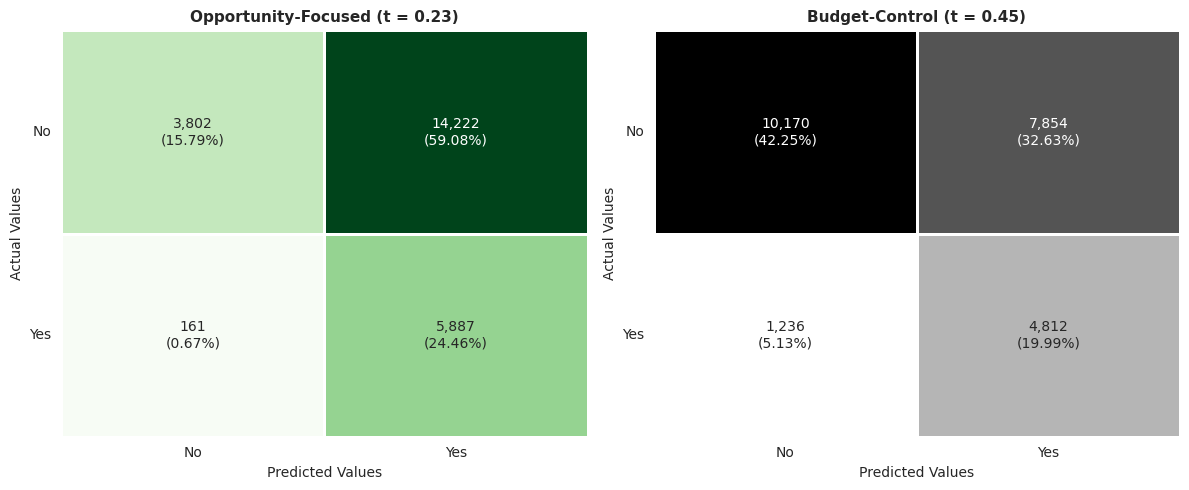

In [101]:
def plot_two_confusion_matrices(y_true, y_pred_1, y_pred_2, title_1, title_2):
    cm1 = confusion_matrix(y_true, y_pred_1)
    cm2 = confusion_matrix(y_true, y_pred_2)
    
    cm1_pct = cm1.astype(float) / cm1.sum() * 100
    cm2_pct = cm2.astype(float) / cm2.sum() * 100

    labels1 = np.array([
        [f"{cm1[0,0]:,}\n({cm1_pct[0,0]:.2f}%)", f"{cm1[0,1]:,}\n({cm1_pct[0,1]:.2f}%)"],
        [f"{cm1[1,0]:,}\n({cm1_pct[1,0]:.2f}%)", f"{cm1[1,1]:,}\n({cm1_pct[1,1]:.2f}%)"]
    ])

    labels2 = np.array([
        [f"{cm2[0,0]:,}\n({cm2_pct[0,0]:.2f}%)", f"{cm2[0,1]:,}\n({cm2_pct[0,1]:.2f}%)"],
        [f"{cm2[1,0]:,}\n({cm2_pct[1,0]:.2f}%)", f"{cm2[1,1]:,}\n({cm2_pct[1,1]:.2f}%)"]
    ])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.heatmap(
        cm1_pct, annot=labels1, fmt="", cmap="Greens", cbar=False,
        linewidths=1, linecolor="white",
        xticklabels=["No", "Yes"], yticklabels=["No", "Yes"],
        annot_kws={"size": 10}, ax=axes[0]
    )
    axes[0].set_title(title_1, fontsize=11, fontweight='bold')
    axes[0].set_xlabel("Predicted Values")
    axes[0].set_ylabel("Actual Values")
    axes[0].tick_params(axis='y', rotation=0)

    sns.heatmap(
        cm2_pct, annot=labels2, fmt="", cmap="Greys", cbar=False,
        linewidths=1, linecolor="white",
        xticklabels=["No", "Yes"], yticklabels=["No", "Yes"],
        annot_kws={"size": 10}, ax=axes[1]
    )
    axes[1].set_title(title_2, fontsize=11, fontweight='bold')
    axes[1].set_xlabel("Predicted Values")
    axes[1].set_ylabel("Actual Values")
    axes[1].tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()


plot_two_confusion_matrices(
    y_test,
    pred_test_1,
    pred_test_2,
    f'{scenario_1["name"]} (t = {best_t_1:.2f})',
    f'{scenario_2["name"]} (t = {best_t_2:.2f})'
)

## **10. Connecting all the dots: Recommendations & Conclusion**

### ***10.1 Connecting all the dots: Recommendations***

1. Prioritise early investment in tracks with high-potential
2. Adopting a tiered marketign strategy
3. Levereaging audio insights in production and marketing decisions process

### ***10.2 Limitations and possible further analysis***

- Artist influence not included
- chagning market trends
- impact of social media and variality
- marketing and promotion factors
- model is ultimately based on historical patterns and may not fully predict future trends in a fast-changing industry

### ***10.3 Overall Conclusion***

## **11. Hands-on: Choosing your favourite songs!**

**Note: The data only consists of songs up to around 2022 - so Taylor Swift's latest album cannot be found!*

In [ ]:
def lookup_artist(artist_name):
    mask    = df_clean['artists'].str.lower().str.contains(artist_name.lower().strip(), na=False)
    matches = df_clean[mask].drop_duplicates('track_name').head(10)

    if matches.empty:
        print(f'No artist found matching "{artist_name}".')
        return None

    print(f'\nTop songs for "{artist_name}":')
    print(f'  {"#":<4} {"Track Name":<50}')
    print(f'  {"-"*55}')
    for idx, (_, row) in enumerate(matches.iterrows()):
        print(f'  {idx+1:<4} {row["track_name"]:<50}')

    return matches.reset_index(drop=True)


def lookup_song(song):

    is_hit = song['hit'] == 1

    # Genre signals — aligned with latest SHAP beeswarm
    genre_signals = {
        'pop':            '[+] pop — positive signal',
        'rock_alt':       '[+] rock/alt — positive signal',
        'hiphop_rnb':     '[+] hip-hop/r&b — positive signal',
        'indie_alt':      '[+] indie/alt — moderate positive signal',
        'folk_country':   '[-] folk/country — weak signal',
        'jazz_blues_funk':'[-] jazz/blues/funk — weak signal',
        'classical':      '[-] classical — negative signal',
        'metal':          '[-] metal — weak signal',
        'electronic':     '[-] electronic — weak signal',
        'dance':          '[-] dance — negative signal',
        'latin':          '[-] latin — strong negative (US market bias)',
        'reggae_afro':    '[-] reggae/afro — negative signal',
        'language':       '[-] world music — weak signal',
        'kids':           '[-] kids — strong negative signal',
        'relax':          '[-] relax — negative signal',
        'other':          '[-] other — weak signal',
    }
    genre_good   = str(song['genre_group']) in ['pop', 'rock_alt', 'hiphop_rnb', 'indie_alt']
    genre_signal = genre_signals.get(str(song['genre_group']), '[-] unknown genre')

    print('=' * 55)
    print(f'  {"[HIT]" if is_hit else "[NOT A HIT]"}  {song["track_name"]} — {song["artists"]}')
    print(f'  Genre: {song["genre_group"]}  |  Popularity: {int(song["popularity"])}/100  |  Threshold: {int(hit_threshold)}')
    print('=' * 55)

    # Features breakdown — directions from SHAP beeswarm
    # Loudness:         HIGH = better  (red = RIGHT)
    # Energy:           LOW  = better  (red = LEFT)
    # Instrumentalness: LOW  = better  (red = LEFT)
    # Acousticness:     LOW  = better  (red = LEFT)
    # Danceability:     HIGH = better  (red = RIGHT)
    # Liveness:         LOW  = better  (red = LEFT)
    # Valence:          HIGH = better  (red = RIGHT)
    # Mood Intensity:   HIGH = better  (red = slightly RIGHT)
    features_check = [
        ('Genre',            None,                    genre_good,                      genre_signal,                      None),
        ('Loudness',         song['loudness'],         song['loudness'] > -8,           f'{song["loudness"]:.1f} dB',      None),
        ('Energy',           song['energy'],           song['energy'] < 0.7,            f'{song["energy"]:.3f}',           None),
        ('Instrumentalness', song['instrumentalness'], song['instrumentalness'] < 0.1,  f'{song["instrumentalness"]:.3f}', None),
        ('Acousticness',     song['acousticness'],     song['acousticness'] < 0.3,      f'{song["acousticness"]:.3f}',     None),
        ('Danceability',     song['danceability'],     song['danceability'] > 0.6,      f'{song["danceability"]:.3f}',     None),
        ('Liveness',         song['liveness'],         song['liveness'] < 0.3,          f'{song["liveness"]:.3f}',         None),
        ('Valence',          song['valence'],          song['valence'] > 0.4,           f'{song["valence"]:.3f}',          None),
        ('Mood Intensity',   song['mood_intensity'],   song['mood_intensity'] > 0.3,    f'{song["mood_intensity"]:.3f}',   None),
    ]

    print(f'\n  {"Feature":<20} {"Value":>12}   Signal')
    print(f'  {"-"*50}')

    score = 0
    for label, _, good, val, _ in features_check:
        icon = '[+]' if good else '[-]'
        score += int(good)
        if label == 'Genre':
            print(f'  {label:<20} {"":>12}   {genre_signal}')
        else:
            print(f'  {label:<20} {val:>12}   {icon}')

    print(f'\n  Feature score: {score}/9 features align with hit profile')

    # Diagnosis if popular but not a hit
    if not is_hit and song['popularity'] >= 50:
        print('\n  Why is this song not classified as a hit?')
        reasons = []
        if song['popularity'] < hit_threshold:
            reasons.append(f'Popularity ({int(song["popularity"])}) is below the 75th percentile threshold ({int(hit_threshold)})')
        if not genre_good:
            reasons.append(f'Genre ({song["genre_group"]}) is not among top-performing genres in US streaming data')
        if song['energy'] > 0.7:
            reasons.append('Very high energy — model penalises extremely energetic tracks')
        if song['acousticness'] > 0.5:
            reasons.append('High acousticness — produced/electronic sound dominates streaming hits')
        if song['instrumentalness'] > 0.3:
            reasons.append('High instrumentalness — model strongly prefers vocal-led tracks')
        if song['liveness'] > 0.4:
            reasons.append('High liveness — model prefers clean studio recordings')
        if song['loudness'] < -12:
            reasons.append('Low loudness — louder productions consistently perform better on streaming')
        if song['danceability'] < 0.4:
            reasons.append('Low danceability — more danceable tracks perform better on streaming')
        if song['valence'] < 0.2:
            reasons.append('Very low valence — very dark/sad tracks tend to underperform')
        if not reasons:
            reasons.append('Audio features are borderline — no single culprit')
            reasons.append('Popularity may have decayed since release (Spotify weights recent plays)')
            reasons.append('Success driven by non-audio factors (marketing, artist fame, cultural moment)')
        for r in reasons:
            print(f'  - {r}')
    print()


# Run the tool
while True:
    artist_input = input('Artist name (or "quit"): ').strip()
    if artist_input.lower() in ['quit', 'q', 'exit', '']:
        break

    matches = lookup_artist(artist_input)
    if matches is None:
        continue

    num_input = input('Select a song number (1-10): ').strip()
    if not num_input.isdigit() or not (1 <= int(num_input) <= len(matches)):
        print('Invalid selection.')
        continue

    print()
    lookup_song(matches.iloc[int(num_input) - 1])
    print()